### Performing a preliminary data exploration

Aim: get a sense of the data, it's structure, quality, and key characteristics before further analysis.

The EDA Steps:
- Check for Duplicates: Identify and remove identical rows.
- Handle Missing Values: Address NaNs using imputation or removal.
- Data Type Validation: Convert data types where necessary.
- Detect Outliers: Use statistical methods or visualizations.
- Feature Engineering: Create new meaningful features.
- Data Normalization & Transformation: Standardization, scaling, or encoding.
- Exploratory Visualizations: Histograms, boxplots, correlation heatmaps.
- Statistical Tests: Checking relationships between variables.


In [85]:
# Requires Python 3.11.0
# -*- coding: utf-8 -*-
"""
This script reads data from a SQLite database and performs EDA or exploratory data analysis.
In the EDA, it generates both Descritive statistics and Visualizations of data to better understand requirements.
It also includes implementation of the Classification models.

The data, stored in a SQLite database, is connected and read as a dataframe.
"""
# Import libraries required for accessing the SQLite database and dataframes for data processing
# Ensure all required libraries are installed

import sqlite3 # for SQLite database connection
import pandas as pd # libraries
import matplotlib.pyplot as plt # for plotting graphs
import seaborn as sns # for advanced plotting
import numpy as np # for numerical operations
import yaml # for reading YAML files
import os # for checking file existence
from scipy.stats import spearmanr


Some functions to be used in the script

In [86]:
# To assist in EDA process, the following functions are defined:
# Prints separator to console for better readability
def print_separator():
    """
    This function performs print a separator line to the console.
    """
    print("."*30)

In [87]:
# Put the following as a routine to check for outliers

def outliers_for_removal(df, column, threshold,lower_bound=False, upper_bound=True):
    """
    This function checks for outliers in a given column of the dataframe using the IQR method.
    """
    Q1 = df[column].quantile(0.25) # 25th percentile
    Q3 = df[column].quantile(0.75) # 75th percentile
    IQR = Q3 - Q1 # Interquartile range

    if lower_bound == True:
        # Calculate lower bound for outliers
        lower_bound = Q1 - threshold * IQR
    else:
        # Calculate lower bound for outliers
        lower_bound = min(df[column])

    # Print the lower bound for outliers
    print(f"Lower bound for outliers in {column}: {lower_bound}")

    if upper_bound == True:
        # Calculate upper bound for outliers
        upper_bound = Q3 + threshold * IQR
    else:
        # Calculate upper bound for outliers
        upper_bound = max(df[column])

    # Print the upper bound for outliers
    print(f"Upper bound for outliers in {column}: {upper_bound}")

    # Remove outliers from the dataframe using lower and upper bounds
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    print(f"Removed outliers from the column: {column}, with threshold: {threshold}")
    print_separator()
    return df

In [88]:
# Define the path to the config.yaml file
config_path = './src/config.yaml'

# Check if the file exists
if os.path.exists(config_path):
    # Load configuration from a YAML file as encoding='utf-8'
    with open(config_path, 'r', encoding='utf-8') as file: # open the config.yaml file
        config = yaml.safe_load(file) # load the configuration

    # Get "database_path" from config.yaml
    if 'database_path' in config:
        database_path = config['database_path'] # get the database path
        print('The database path is:', database_path,"n")
    else:
        print("Error: 'database_path' key is missing in the configuration.")        
    print_separator()
       
    print_separator()
    # Get "classification_target" from config.yaml
    if 'classification_target' in config:
        target_column_discrete = config['classification_target'] 
        print('The target column (Classification) is:', target_column_discrete)
    else:
        print("Error: 'classification_target' key is missing in the configuration.")
else:
    print(f"Error: The file '{config_path}' does not exist. Please check the file path.")

The database path is: ./data/bmarket.db n
..............................
..............................
The target column (Classification) is: Subscription Status


In [89]:
# Open database and create a pandas dataframe
# Connect to the SQLite database using the path from config.yaml
conn = sqlite3.connect(database_path)

# Check if the connection was successful
if conn is None:
	print("Error: Unable to connect to the database.")
	print_separator()
else:
	print("Database connection successful.")
	print_separator()

	# Read Table Name from database
	table_name_df = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)

	# Check if table_name_df is empty
	if table_name_df.empty:
		print("Error: No tables found in the database.")
	else:
		# Extract Table Name from database
		table_name = table_name_df['name'].values[0]
		# Print Table Name of database
		print('Database table name: ', table_name)
		# Create a pandas dataframe from database
		df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn) # Load the dataset

# Close database connection
conn.close()


Database connection successful.
..............................
Database table name:  bank_marketing


In [90]:
# Save the dataframe to a CSV file using path and filename as stated in
# initial_dataset_csv_file_path from config.yaml
if 'initial_dataset_csv_file_path' in config:
	initial_dataset_csv_file_path = config['initial_dataset_csv_file_path']
	# Save the dataframe to a CSV file
	df.to_csv(initial_dataset_csv_file_path, index=False)
	print(f"Dataframe saved to {initial_dataset_csv_file_path}")

Dataframe saved to ./data/bmarket.csv


#### Getting a quick look

In [91]:
# The database is loaded properly and the first 5 rows of the dataframe are printed to check 
# if the data is read correctly. Also it gives a sense of the data's structure and content
df.head()

,Client ID,Age,Occupation,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status
0,32885,57 years,technician,married,high.school,no,no,yes,Cell,1,999,no
1,3170,55 years,unknown,married,unknown,unknown,yes,no,telephone,2,999,no
2,32207,33 years,blue-collar,married,basic.9y,no,no,no,cellular,1,999,no
3,9404,36 years,admin.,married,high.school,no,no,no,Telephone,4,999,no
4,14021,27 years,housemaid,married,high.school,no,None,no,Cell,2,999,no


In [92]:
# Provides a concise summary and display the number of non-null entries, data type, the overall memory usage.
# Understanding the shape, size, datatypes of the dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Client ID              41188 non-null  int64 
 1   Age                    41188 non-null  object
 2   Occupation             41188 non-null  object
 3   Marital Status         41188 non-null  object
 4   Education Level        41188 non-null  object
 5   Credit Default         41188 non-null  object
 6   Housing Loan           16399 non-null  object
 7   Personal Loan          37042 non-null  object
 8   Contact Method         41188 non-null  object
 9   Campaign Calls         41188 non-null  int64 
 10  Previous Contact Days  41188 non-null  int64 
 11  Subscription Status    41188 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.8+ MB


#### Findings:
Dataset:s 41188  rows, 11 columns
* mix of object and numerical (int64) data types
* features have null entries/missing values

#### <u>Problem statement</u>

Predicting the likelihood that a client, from AI-Vive-Banking, will subscribe to a term deposit, based on client information and also data from direct marketing campaigns.

Objective: To perform **Classification ("yes", "no") of the Subscription Status**.

The dataset consists of the following features:

1. Age
2. Occupation
3. Marital Status
4. Education Level
5. Credit Default
6. Housing Loan
7. Personal Loan
8. Contact Method
9. Campaign Calls
10. Previous Contact Days
11. Subscription Status (Target)

This dataset will be used to develop the classification models to predict the Subscription Status of the client, enabling the bank to enhance their **resource allocation** for customer engagement.

The outcome aims to streamline the bank operations to improve its **financial performance**.

After understanding the data types with respect to the problem statements, the preparation of data can be performed before the actual EDA.

In [93]:
# Calculate initial number of rows and columns in dataframe
initial_row_count = len(df)
# Print Number of Rows in dataframe
print(f"Initial number of rows: {initial_row_count}")
initial_column_count = len(df.columns)
# Print Number of Columns in dataframe
print(f"Initial number of columns: {initial_column_count}")
print_separator()

Initial number of rows: 41188
Initial number of columns: 12
..............................


In [94]:
# Reload config.yaml file
with open(config_path, 'r', encoding='utf-8') as file: # open the config.yaml file
    config = yaml.safe_load(file) # load the configuration

# If "ID_column" from config.yaml is not empty, then get the ID column name and 
# remove it from the dataframe
if 'ID_column' in config:
    ID_column = config['ID_column'] # get the ID column name
    if ID_column in df.columns:
        # Since there is an ID column, we can remove this column from the dataframe
        df.drop(columns=[ID_column], inplace=True)
        print(f"Removed '{ID_column}' column from the dataframe.")
    else:
        print(f"'{ID_column}' column not found in the dataframe. No column removed.")

Removed 'Client ID' column from the dataframe.


Looking for duplicates by removal of ID.

In [95]:
# Find the duplicate rows in the dataframe and print the number of duplicate rows
# Check for duplicates in the dataframe
print("Number of duplicates: ", df.duplicated().sum())
# Find the row count of the df
print("Number of rows: ", df.shape[0])
# Calculate the percentage of duplicates to 2 decimal places
# Print the percentage of duplicates to 2 decimal places
print("Percentage of duplicates: ", round(df.duplicated().sum()/df.shape[0]*100, 2), "%")
print_separator()

# Remove duplicate rows from the dataframe
df.drop_duplicates(inplace=True)
# Print the number of duplicate rows after removal
print("Number of duplicates after removal: ", df.duplicated().sum())

# Make a copy of the original dataframe
df_initial = df.copy()

Number of duplicates:  5240
Number of rows:  41188
Percentage of duplicates:  12.72 %
..............................
Number of duplicates after removal:  0


#### Findings:
There are duplicates of > 10% by the removal of the column Client ID. 
* These duplicates are removed.

In [96]:
# To understand the data structures on each feature as to determine validity of the data.

# Print the data types of each feature, its unique values, number of unique values 
# as well as missing values
for col in df.columns:
    print(f"Column name: {col}")
    print(f"Data type: {df[col].dtype}")
    print(f"Number of unique values: {df[col].nunique()}")
    print(f"Unique values: {df[col].unique()}")
    print(f"Number of missing values: {df[col].isnull().sum()}")
    print_separator()

Column name: Age
Data type: object
Number of unique values: 77
Unique values: ['57 years' '55 years' '33 years' '36 years' '27 years' '58 years'
 '48 years' '150 years' '24 years' '34 years' '42 years' '43 years'
 '26 years' '37 years' '46 years' '59 years' '49 years' '30 years'
 '51 years' '45 years' '31 years' '41 years' '38 years' '47 years'
 '69 years' '50 years' '25 years' '39 years' '44 years' '52 years'
 '35 years' '77 years' '40 years' '56 years' '53 years' '60 years'
 '29 years' '28 years' '54 years' '32 years' '81 years' '63 years'
 '21 years' '22 years' '74 years' '80 years' '62 years' '68 years'
 '86 years' '23 years' '71 years' '67 years' '65 years' '20 years'
 '19 years' '66 years' '75 years' '18 years' '72 years' '70 years'
 '82 years' '85 years' '61 years' '88 years' '83 years' '78 years'
 '64 years' '17 years' '76 years' '73 years' '79 years' '89 years'
 '84 years' '91 years' '98 years' '92 years' '95 years']
Number of missing values: 0
..............................
C

Looking for missing values.

In [97]:
# Check for missing values in the dataframe, print the column name, the number of missing values and the percentage of missing values
missing_values = df.isnull().sum()
total_rows = len(df)
for column, count in missing_values.items():
	percentage = (count / total_rows) * 100
	print(f"Column: {column}, Missing count: {count} -> {percentage:.2f}%")

Column: Age, Missing count: 0 -> 0.00%
Column: Occupation, Missing count: 0 -> 0.00%
Column: Marital Status, Missing count: 0 -> 0.00%
Column: Education Level, Missing count: 0 -> 0.00%
Column: Credit Default, Missing count: 0 -> 0.00%
Column: Housing Loan, Missing count: 20718 -> 57.63%
Column: Personal Loan, Missing count: 4013 -> 11.16%
Column: Contact Method, Missing count: 0 -> 0.00%
Column: Campaign Calls, Missing count: 0 -> 0.00%
Column: Previous Contact Days, Missing count: 0 -> 0.00%
Column: Subscription Status, Missing count: 0 -> 0.00%


#### Findings:
High missing values for columns Housing Loan and Personal Loan

#### <u>Performing preliminary data cleaning before EDA.</u>

Convert the string to lowercase

In [98]:
# To correct the data format, for all categorical features, convert the values to lowercase
# for all categorical features, convert the values to lowercase
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.lower()
print ("Converted categorical values to lowercase.")

# Check for duplicates in the dataframe
print("Number of duplicates: ", df.duplicated().sum())

Converted categorical values to lowercase.
Number of duplicates:  877


Re-checking for duplicates

In [99]:
# Find the duplicate rows in the dataframe and print the number of duplicate rows
# Check for duplicates in the dataframe
print("Number of duplicates: ", df.duplicated().sum())
# Find the row count of the df
print("Number of rows: ", df.shape[0])
# Calculate the percentage of duplicates to 2 decimal places
# Print the percentage of duplicates to 2 decimal places
print("Percentage of duplicates: ", round(df.duplicated().sum()/df.shape[0]*100, 2), "%")
print_separator()

# Remove duplicate rows from the dataframe
df.drop_duplicates(inplace=True)
# Print the number of duplicate rows after removal
print("Number of duplicates after removal: ", df.duplicated().sum())

Number of duplicates:  877
Number of rows:  35948
Percentage of duplicates:  2.44 %
..............................
Number of duplicates after removal:  0


In [100]:
# In col Contact Method, the value 'cell' is rename as 'cellular'
df['Contact Method'] = df['Contact Method'].replace({'cell': 'cellular'})
print("Renamed 'cell' to 'cellular' in Contact Method column.")

Renamed 'cell' to 'cellular' in Contact Method column.


In [101]:
# Get the "data_type_correction" from config.yaml
if 'data_type_correction' in config:
    # For each data_type_correction, if it is an object, convert it to a int by removing the string portion
    df[config['data_type_correction']] = df[config['data_type_correction']].str.extract('(\d+)').astype(int)
else:
    print("Error: 'data_type_correction' key is missing in the configuration.")

Check for negative values that are not valid

In [102]:
# Statistics of the column 'Age' in the dataframe
# Check if Age column exists in the dataframe
if 'Age' not in df.columns:
    print("Error: 'Age' column not found in the dataframe.")
else:
    print("Statistics of the column 'Age':")
    print(df['Age'].describe())
    print_separator()

    # Since Age cannot be negative, check for negative values in the Age column
    print("Negative values in the Age column: ", df[df['Age'] < 0].shape[0])
    print_separator()

    # Check for values greater than 100 in the Age column
    print("Values greater than 100 in the Age column: ", df[df['Age'] > 100].shape[0])
    print_separator()

    # Print the percentage of this group
    print("Percentage of Age > 100 group: ", round(df[df['Age'] > 100].shape[0]/df.shape[0]*100, 2), "%")
    print_separator()

Statistics of the column 'Age':
count    35071.000000
mean        50.425081
std         33.097209
min         17.000000
25%         33.000000
50%         40.000000
75%         51.000000
max        150.000000
Name: Age, dtype: float64
..............................
Negative values in the Age column:  0
..............................
Values greater than 100 in the Age column:  3188
..............................
Percentage of Age > 100 group:  9.09 %
..............................


In [103]:
# For values greater than 100 in the Age column, describe 10 random rows in the df
if 'Age' not in df.columns:
    print("Error: 'Age' column not found in the dataframe.")
else:
	rows_with_age_gt_100 = df[df['Age'] > 100]
	if not rows_with_age_gt_100.empty:
		print("10 random rows with values greater than 100 in the Age column:")
		print(rows_with_age_gt_100.sample(10, random_state=42))
	else:
		print("No rows with values greater than 100 in the Age column.")
	print_separator()

10 random rows with values greater than 100 in the Age column:
       Age    Occupation Marital Status      Education Level Credit Default  \
10780  150    technician        married    university.degree             no   
10530  150    technician        married    university.degree             no   
8171   150   blue-collar        married             basic.6y        unknown   
4033   150  entrepreneur         single  professional.course             no   
11880  150       student         single              unknown             no   
6174   150   blue-collar       divorced             basic.9y             no   
6149   150    technician        married  professional.course             no   
16383  150      services         single              unknown             no   
1287   150   blue-collar        married             basic.6y             no   
21300  150   blue-collar        married             basic.9y             no   

      Housing Loan Personal Loan Contact Method  Campaign Calls  \


#### Findings:
Instead of removing values in Age column that is > 100, imputting with mean, within the < 100 range, will keep the data size intact for useful analysis.

In [104]:
# Replace values greater than 100 in the Age column with mean of the column taken from only when Age is less than 100
if 'Age' not in df.columns:
    print("Error: 'Age' column not found in the dataframe.")
else:
    mean_age = df[df['Age'] < 100]['Age'].mean()
    df.loc[df['Age'] > 100, 'Age'] = mean_age.astype(df['Age'].dtype)
    print("Impute Age values that are > 100, with mean from the Age range < 100.")
    print_separator()

Impute Age values that are > 100, with mean from the Age range < 100.
..............................


Re-checking for duplicates

In [105]:
# Check for duplicates of the df
print("Number of duplicates: ", df.duplicated().sum())

# Find the row count of the df
print("Number of rows: ", df.shape[0])

# Calculate the percentage of duplicates to 2 decimal places
print("Percentage of duplicates: ", round(df.duplicated().sum()/df.shape[0]*100, 2), "%")  

Number of duplicates:  2220
Number of rows:  35071
Percentage of duplicates:  6.33 %


#### Findings:
At this stage, the size of duplicates increases from 12% to 20%

Check for the columns with values as "unknown"

In [106]:
# For columns with "unknown" values, print the column name, the number of unique values and the percentage of "unknown" values 
# in the column
for col in df.columns:
    if df[col].dtype == 'object':
        unknown_count = df[col].str.contains('unknown', case=False, na=False).sum()
        if unknown_count > 0:
            print(f"Column: {col}")
            print(f"Number of unique values: {df[col].nunique()}")
            print(f"Percentage of 'unknown' values: {round(unknown_count/df.shape[0]*100, 2)}%")
            print_separator()


Column: Occupation
Number of unique values: 12
Percentage of 'unknown' values: 0.91%
..............................
Column: Marital Status
Number of unique values: 4
Percentage of 'unknown' values: 0.23%
..............................
Column: Education Level
Number of unique values: 8
Percentage of 'unknown' values: 4.74%
..............................
Column: Credit Default
Number of unique values: 3
Percentage of 'unknown' values: 22.26%
..............................
Column: Housing Loan
Number of unique values: 3
Percentage of 'unknown' values: 1.1%
..............................
Column: Personal Loan
Number of unique values: 3
Percentage of 'unknown' values: 2.46%
..............................


#### Finding: 

There are 6 columns with "unknown" values, ranging from less than 1% to 20% of the dataset

Column: Occupation
* Number of unique values: 12
* Percentage of 'unknown' values: 0.81%

Column: Marital Status
* Number of unique values: 4
* Percentage of 'unknown' values: 0.19%

Column: Education Level
* Number of unique values: 8
* Percentage of 'unknown' values: 4.26%

Column: Credit Default
* Number of unique values: 3
* Percentage of 'unknown' values: 20.86%

Column: Housing Loan
* Number of unique values: 3
* Percentage of 'unknown' values: 0.95%

Column: Personal Loan
* Number of unique values: 3
* Percentage of 'unknown' values: 2.12%

The strategy is to **remove the rows** from the columns that have 'unknown' values of **< 5%** of the dataset, as this will not significantly affect the dataset.

In [107]:
# For each column, if the percentage of 'unknown' values is less than 5%, remove the rows from the dataframe
for col in df.columns:
    if df[col].dtype == 'object':
        unknown_count = df[col].str.contains('unknown', case=False, na=False).sum()
        if unknown_count > 0:
            percentage_unknown = round(unknown_count/df.shape[0]*100, 2)
            if percentage_unknown < 5:
                df = df[~df[col].str.contains('unknown', case=False, na=False)]
                print(f"Removed rows with 'unknown' values from column: {col}")
                print_separator()
            else:
                print(f"Percentage of 'unknown' values in column {col} is greater than 5%. No rows removed.")
                print_separator()

Removed rows with 'unknown' values from column: Occupation


..............................
Removed rows with 'unknown' values from column: Marital Status
..............................
Removed rows with 'unknown' values from column: Education Level
..............................
Percentage of 'unknown' values in column Credit Default is greater than 5%. No rows removed.
..............................
Removed rows with 'unknown' values from column: Housing Loan
..............................
Removed rows with 'unknown' values from column: Personal Loan
..............................


#### Findings:
For Credit Default, the percentage of 'unknown' values is about 20%.

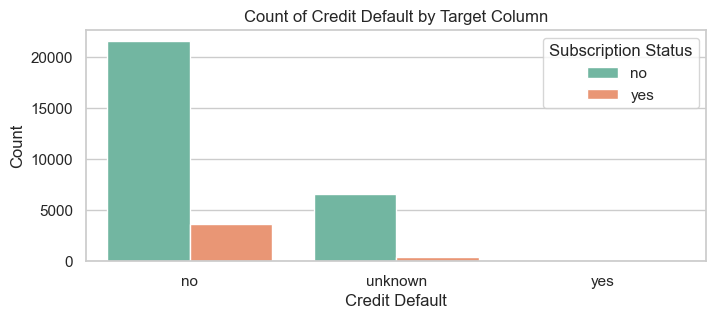

In [108]:
# Plot the bar plot of only the column Credit Default, wrt to the target column
plt.figure(figsize=(8, 3))
sns.countplot(data=df, x='Credit Default', hue=target_column_discrete, palette='Set2')
plt.title('Count of Credit Default by Target Column')
plt.xlabel('Credit Default')
plt.ylabel('Count')
plt.legend(title=target_column_discrete)
plt.show()

In [109]:
# For Credit Default, print the number for each unique value only for values = 'yes'
print("Number of 'yes' values in Credit Default column: ", df[df['Credit Default'] == 'yes'].shape[0])
# Print the percentage of 'yes' values in Credit Default column
print("Percentage of 'yes' values in Credit Default column: ", round(df[df['Credit Default'] == 'yes'].shape[0]/df.shape[0]*100, 2), "%")
print_separator()

Number of 'yes' values in Credit Default column:  3
Percentage of 'yes' values in Credit Default column:  0.01 %
..............................


#### Finding:
For value of **'yes'** in Credit Default, the positive subscription is **< 0.01%**.
* These rows of value 'yes' can be removed.

In [110]:
# Since the value 'yes' in the Credit Default column is not useful, we can remove it from the dataframe
df = df[df['Credit Default'] != 'yes']
print("Removed 'yes' values from the Credit Default column.")

Removed 'yes' values from the Credit Default column.


#### Findings:
For Credit Default column, addressing how to handle values of 'unknown'
* Instead of removal, these value can be better addressed by renaming as "undisclosed".
* This is to provide better understanding of the data.

In [111]:
# Rename the 'unknown' values to 'undisclosed' in the Credit Default column, for better understanding of the data
df['Credit Default'] = df['Credit Default'].replace('unknown', 'undisclosed')

Checking for invalid values or negative values which are not valid

In [112]:
# For each numerical feature, print the column name, the number of negative values and the percentage of negative values
for col in df.select_dtypes(include='number').columns:
    print(f"Column: {col}")
    print(f"Number of negative values: {df[col].lt(0).sum()}")
    # Print the percentage of negative values to 2 decimal places
    print(f"Percentage of negative values: {round(df[col].lt(0).sum()/df.shape[0]*100, 2)}%")
    print_separator()

Column: Age
Number of negative values: 0
Percentage of negative values: 0.0%
..............................
Column: Campaign Calls
Number of negative values: 3736
Percentage of negative values: 11.58%
..............................
Column: Previous Contact Days
Number of negative values: 0
Percentage of negative values: 0.0%
..............................


#### Findings:
For column Campaign Calls, there are negative values which are not valid.

A look at 'Campaign Calls'

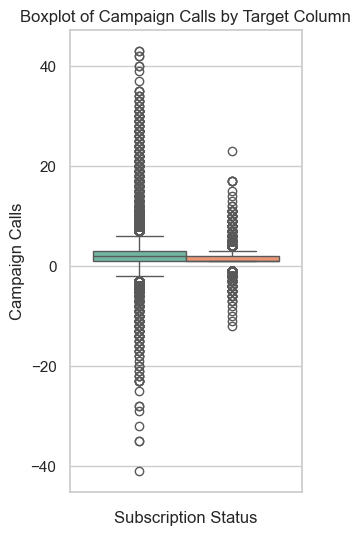

In [113]:
# For Campaign Calls, plot the boxplot of the column Campaign Calls, wrt to the target column
plt.figure(figsize=(3, 6))
sns.boxplot(data=df, y='Campaign Calls', hue=target_column_discrete, x=None, palette='Set2', legend=False)
plt.title('Boxplot of Campaign Calls by Target Column')
plt.xlabel(target_column_discrete)
plt.ylabel('Campaign Calls')
plt.show()

#### Findings:
From the boxplot of 'Campaign Calls' column, there are:
1. outliers
2. negative values

Also, from the boxplot, it appears that successful campaign calls are less successful with increased number of calls.

In [114]:
# For Campaign Calls, convert the negative values to positive values
df['Campaign Calls'] = df['Campaign Calls'].abs()
print("Converted negative values to positive values in Campaign Calls column.")

Converted negative values to positive values in Campaign Calls column.


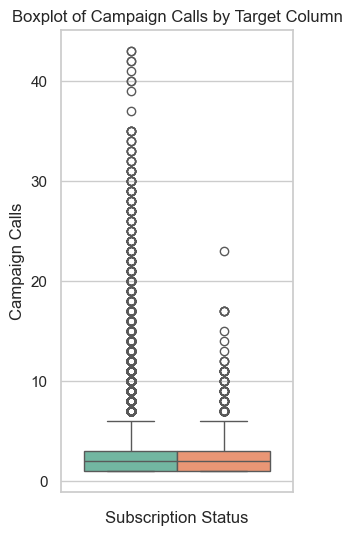

In [115]:
# For Campaign Calls, plot the boxplot of the column Campaign Calls, wrt to the target column
plt.figure(figsize=(3, 6))
sns.boxplot(data=df, y='Campaign Calls', hue=target_column_discrete, x=None, palette='Set2', legend=False)
plt.title('Boxplot of Campaign Calls by Target Column')
plt.xlabel(target_column_discrete)
plt.ylabel('Campaign Calls')
plt.show()

#### Findings:
Campaign Calls seems to be ineffective from persistent callings. This feature can be considered to be dropped off.

A look at 'Previous Contact Days'

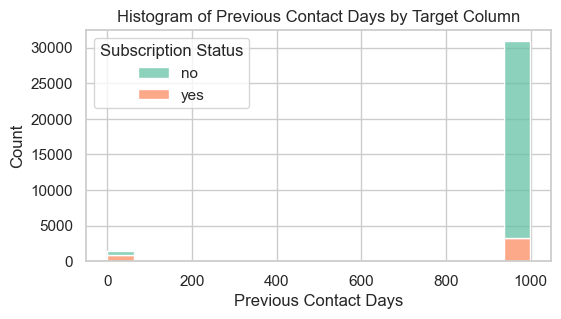

In [116]:
# For Previous Contact Days, plot the histogram of the column Previous Contact Days, wrt to the target column
plt.figure(figsize=(6, 3))  
sns.histplot(data=df, x='Previous Contact Days', hue=target_column_discrete, multiple='stack', palette='Set2')
plt.title('Histogram of Previous Contact Days by Target Column')
plt.xlabel('Previous Contact Days')
plt.ylabel('Count')
plt.show()

In [117]:
# Describe the column Previous Contact Days
print("Statistics of the column Previous Contact Days:")
print(df['Previous Contact Days'].describe())
print_separator()

Statistics of the column Previous Contact Days:
count    32272.000000
mean       957.059556
std        199.727382
min          0.000000
25%        999.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: Previous Contact Days, dtype: float64
..............................


#### From the 'List of Attributes', Previous Contact Days with '999' means 'no prior contact'.

* Replaced '0' with '999' as 'no prior contact'
* Replace remaining as 'prior contact'

Copy the column 'Previous Contact Days' as new column 'Previous Contact' but change its data type to object.

In [118]:
# Copy 'Previous Contact Days' as 'Previous Contact'
df['Previous Contact'] = df['Previous Contact Days']
# Print the copy is done
print("Copied 'Previous Contact Days' as 'Previous Contact'")

Copied 'Previous Contact Days' as 'Previous Contact'


In [119]:
# For 'Previous Contact', replace row value '999' with '0'
df['Previous Contact'] = df['Previous Contact'].replace(999, 0)

# Change the data type of 'Previous Contact' to an object
df['Previous Contact'] = df['Previous Contact'].astype('object')

# For each non-zero value in the 'Previous Contact' column, change the value to '1'
df.loc[df['Previous Contact'] != 0, 'Previous Contact'] = 1

In [120]:
# Change the data type of 'Previous Contact' to an object
df['Previous Contact'] = df['Previous Contact'].astype('object')

# Rename each value in the 'Previous Contact' column from 0 to 'no prior contact'
df['Previous Contact'] = df['Previous Contact'].replace({0: 'no prior contact'})

# Rename each value in the 'Previous Contact' column from 1 to 'prior contact'
df['Previous Contact'] = df['Previous Contact'].replace({1: 'prior contact'})

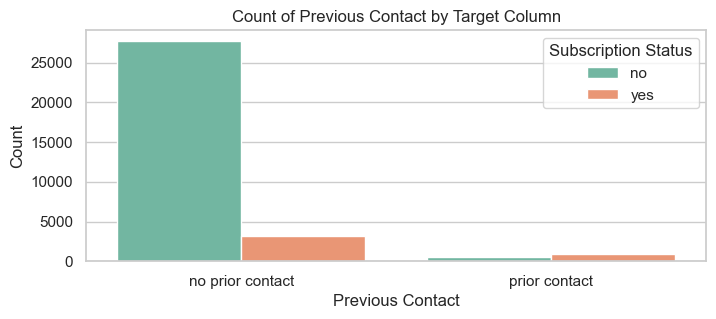

In [121]:
# Plot the bar chart of the column Previous Contact, wrt to the target column
plt.figure(figsize=(8, 3))
sns.countplot(data=df, x='Previous Contact', hue=target_column_discrete, palette='Set2')
plt.title('Count of Previous Contact by Target Column')
plt.xlabel('Previous Contact')
plt.ylabel('Count')
plt.legend(title=target_column_discrete)
plt.show()

In [122]:
# Drop the column Previous Contact Days, if it exists
if 'Previous Contact Days' in df.columns:
    df.drop(columns=['Previous Contact Days'], inplace=True)
    print("Dropped Previous Contact Days column.")
else:
    print("Previous Contact Days column not found. No column dropped.")

Dropped Previous Contact Days column.


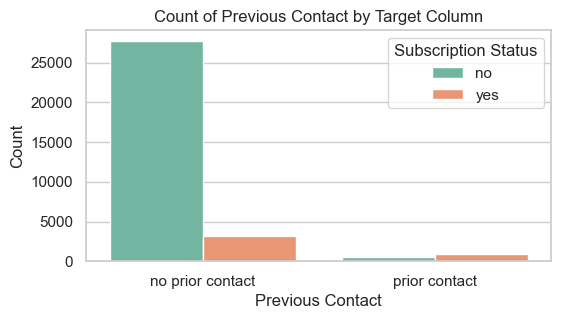

In [123]:
# For Previous Contact, plot the barplot of the column Previous Contact, wrt to the target column
plt.figure(figsize=(6, 3))
sns.countplot(data=df, x='Previous Contact', hue=target_column_discrete, palette='Set2')
plt.title('Count of Previous Contact by Target Column')
plt.xlabel('Previous Contact')
plt.ylabel('Count')
plt.legend(title=target_column_discrete)
plt.show()

#### Findings:
Boxplot of 'Previous Contact' column showed the data type change from numerical to object, with 2 distinct records.
* 'no prior contact'
* 'prior contact'

Checking for missing or null values

In [124]:
# Check for missing values in the dataframe, print the column name, the number of missing values and the percentage of missing values
for col in df.columns:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        print(f"Column: {col}")
        print(f"Number of missing values: {missing_count}")
        # Print the percentage of missing values to 2 decimal places
        print(f"Percentage of missing values: {round(missing_count/df.shape[0]*100, 2)}%")
        print_separator()

Column: Housing Loan
Number of missing values: 18418
Percentage of missing values: 57.07%
..............................
Column: Personal Loan
Number of missing values: 3740
Percentage of missing values: 11.59%
..............................


#### Findings:
There are high percentage of missing values in both Housing Loan and Personal Loan

1. Column: Housing Loan
- Number of missing values: 20768
- Percentage of missing values: 60.38%

2. Column: Personal Loan
- Number of missing values: 3515
- Percentage of missing values: 10.22%

Possible reasons for the missing value:
- Not provided
- Not applicable
- Not sure

Visualisation of Housing Loan and Personal Loan

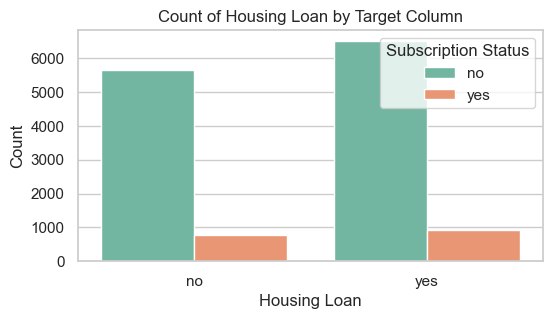

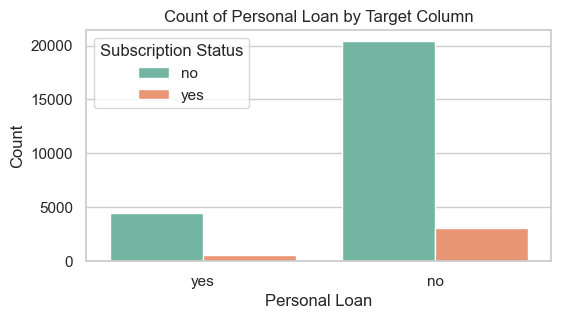

In [125]:
# Plot bar chart of the categorical for Housing Loan and Personal Loan, wrt to the target column
plt.figure(figsize=(6, 3))
sns.countplot(data=df, x='Housing Loan', hue=target_column_discrete, palette='Set2')
plt.title('Count of Housing Loan by Target Column')
plt.xlabel('Housing Loan')
plt.ylabel('Count')
plt.legend(title=target_column_discrete)
plt.show()

# Plot bar chart of the categorical for Housing Loan and Personal Loan, wrt to the target column
plt.figure(figsize=(6, 3))
sns.countplot(data=df, x='Personal Loan', hue=target_column_discrete, palette='Set2')
plt.title('Count of Personal Loan by Target Column')
plt.xlabel('Personal Loan')
plt.ylabel('Count')
plt.legend(title=target_column_discrete)
plt.show()

#### Findings:
From the bar chart, both the Housing Loan and Personal Loan features can be combined to form a new feature that indicates that the client has existing loans. 

* This will make the analysis more effective.

Univariate analysis of categorical columns - using bar charts

* After converting to string to lowercase, renaming similiar strings, removing invalid negative values etc, the plots are shown for a more effective visualisation and possible feature engineering.

In [126]:
# Perfrom Univariate analysis on the categorical features using bar charts
def plot_categorical_features(df):
    """
    This function performs univariate analysis on categorical features using bar charts.
    """
    # Set the style of seaborn
    sns.set_theme(style="whitegrid")

    # Loop through each categorical column in the dataframe
    for col in df.select_dtypes(include='object').columns:
        plt.figure(figsize=(6, 3))
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f"Count of {col}")
        plt.xticks(rotation=45)
        plt.show()

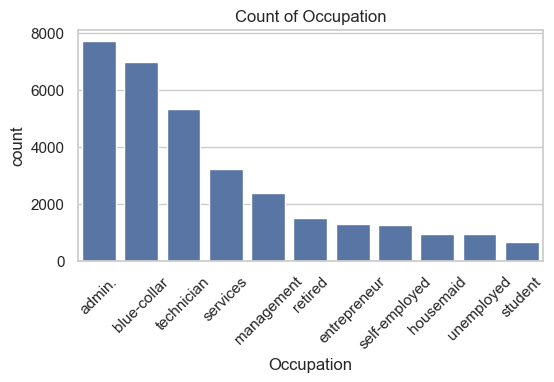

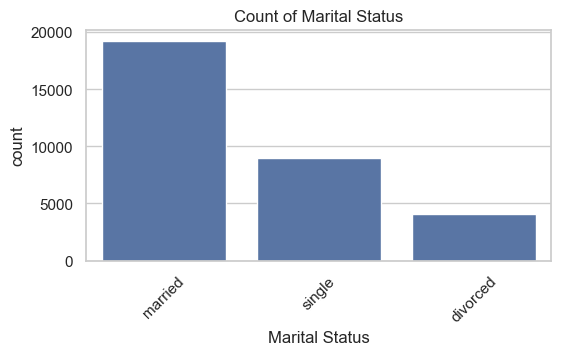

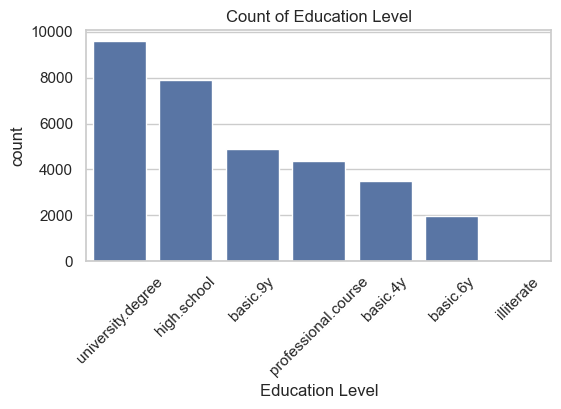

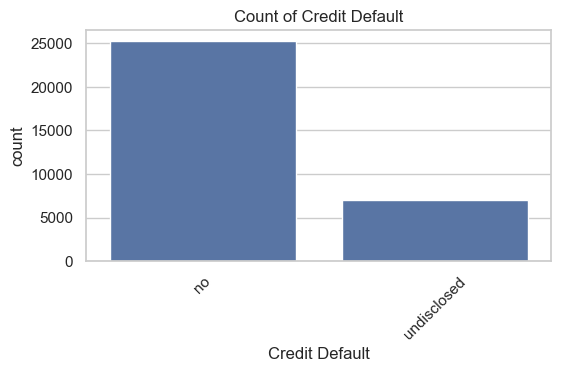

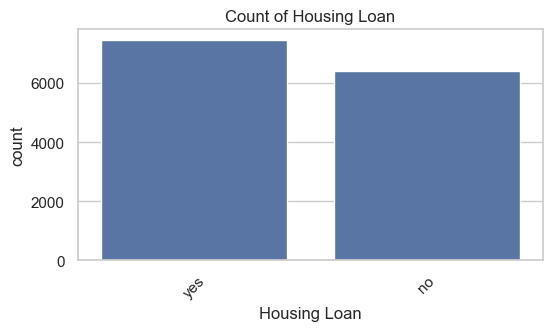

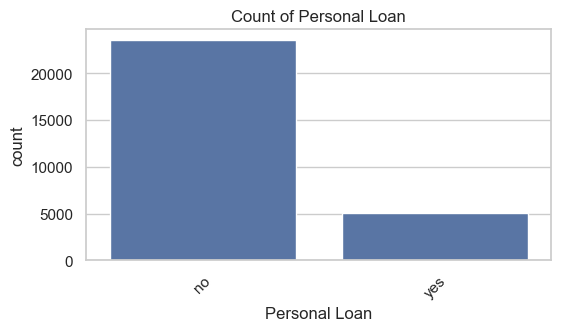

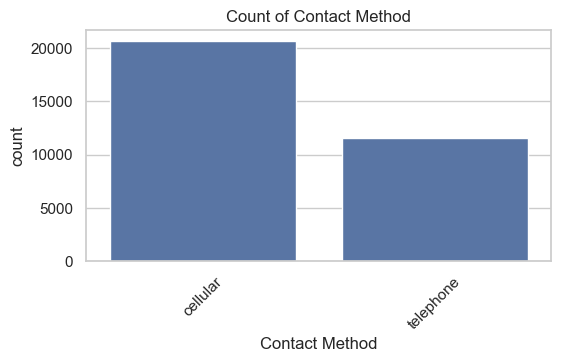

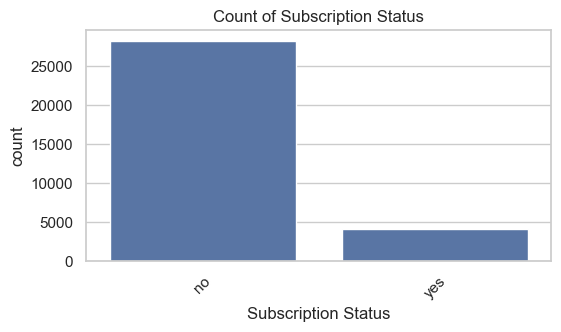

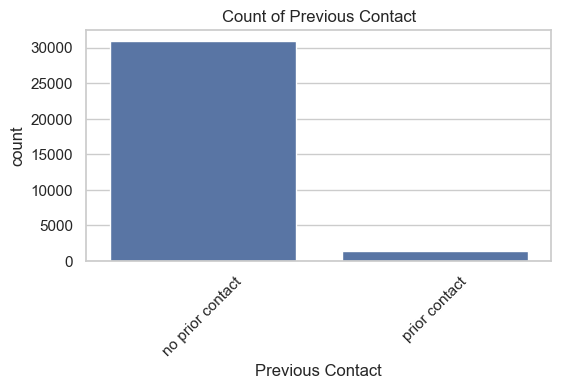

In [127]:
# Run plot_categorical_features
plot_categorical_features(df)

#### Findings:
Results from Univariate analysis of categorical columns

| Column | Feature Engineering options | 
| ------------- | ------------- |
|Occupation | Possible **remapping** the rows values to reduce dimensions (ie as blue-collar, white-collar & grey-collar)|
|Marital Status | **Renamed** 'divorced' as 'single', to remove bias|
|Education Level | Possible **remapping** the row values to reduce dimensions (ie as primary, secondary & tertiary)|
|Credit Default | High count of value 'no', which is a positive attribute|
|Housing Loan | Possible **merging** with other column|
|Personal Loan | Possible **merging **with other column |
|Contact Method | This feaure can be **removed** since the method is voice call, whether via cell or telephone |  
|Previous Contact | The row value '999' and '0' can be **renamed** as 'no prior contact' while the remainder as 'prior contact'|
|Subscription Status | High count of value 'no'. If a model developed has a good performance, the bank operation can greatly benefit by focusing the resource. | 


Univariate analysis of numerical columns - using histograms

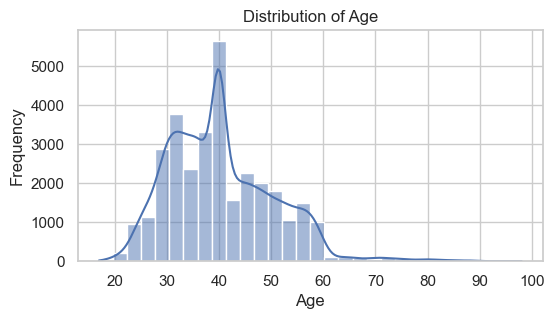

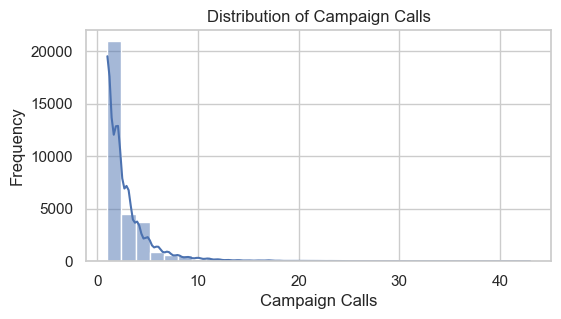

In [128]:
# Perform Univariate analysis on the numerical features using histograms
def plot_numerical_features(df):
    """
    This function performs univariate analysis on numerical features using histograms.
    """
    # Set the style of seaborn
    sns.set_theme(style="whitegrid")

    # Loop through each numerical column in the dataframe
    for col in df.select_dtypes(include='number').columns:
        plt.figure(figsize=(6, 3))
        sns.histplot(data=df, x=col, bins=30, kde=True)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

# Run plot_numerical_features
plot_numerical_features(df)

#### Findings:
Results from Univariate analysis of numerical columns

| Numerical Column | Feature Engineering options  | 
| ------------- | ------------- |
|Age | Options are: **Remove outlier** row with value > 65 or **binning** the age range (ie as 'Twenties', 'Thirties' to 'Above Sixties')| 
|Campaign Calls | **Replace** rows that has value > (mean + 1.5*IQR interquartile range) with the in-range mean| 

#### Bivariate analysis of categorical features - using bar plots

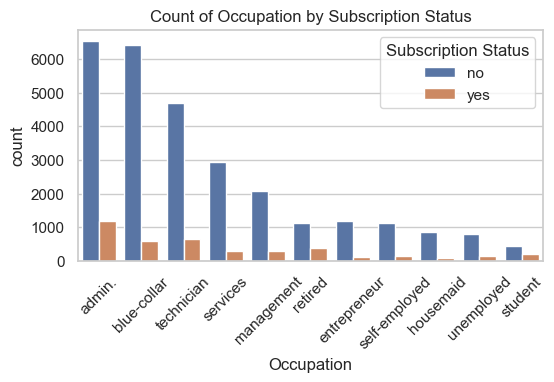

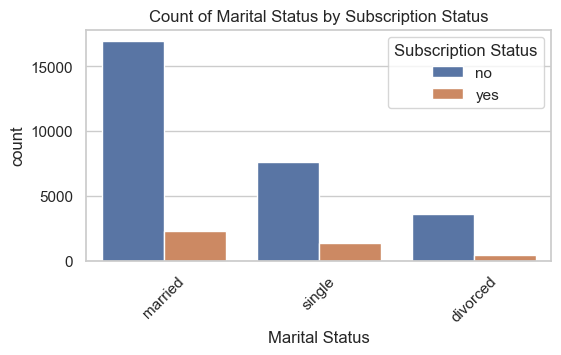

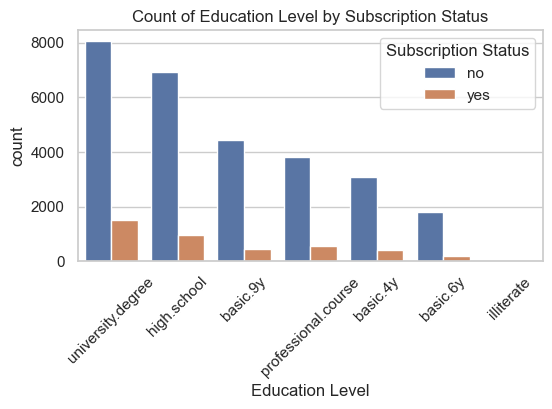

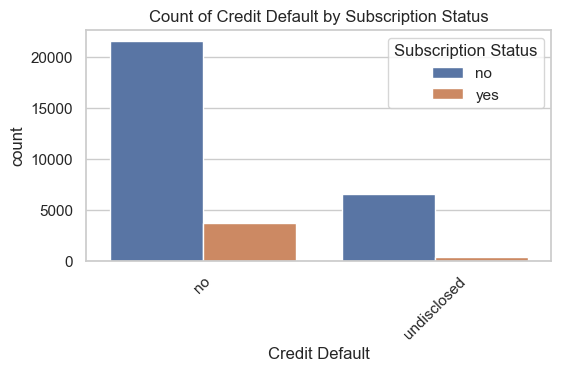

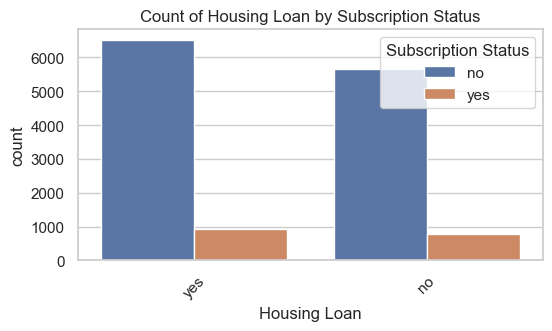

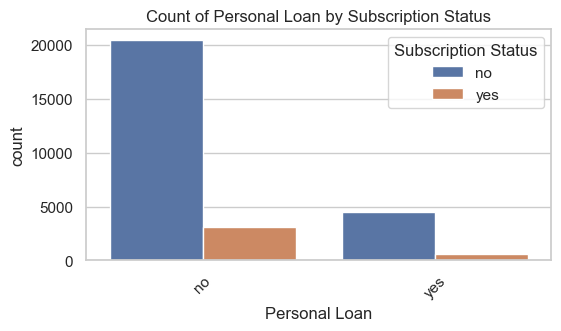

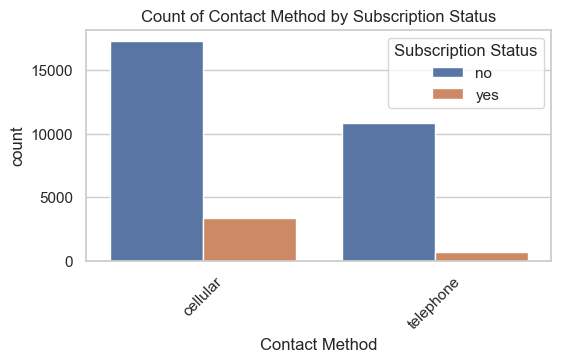

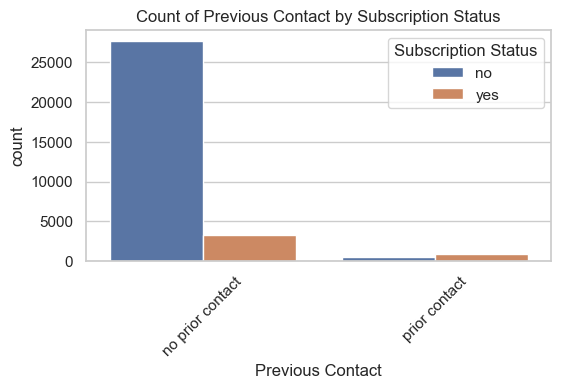

In [129]:
# Perform Bivariate analysis on the categorical features using bar plots
def plot_bivariate_categorical_features(df, target_column):
    """
    This function performs bivariate analysis on categorical features using bar plots.
    """
    # Set the style of seaborn
    sns.set_theme(style="whitegrid")

    # Loop through each categorical column in the dataframe
    for col in df.select_dtypes(include='object').columns:
        if col != target_column:
            plt.figure(figsize=(6, 3))
            sns.countplot(data=df, x=col, hue=target_column, order=df[col].value_counts().index)
            plt.title(f"Count of {col} by {target_column}")
            plt.xticks(rotation=45)
            plt.show()

# Run plot_bivariate_categorical_features
plot_bivariate_categorical_features(df, target_column_discrete)

#### Findings:
Results from bivariate analysis of categorical columns

| Categorical Column | Feature Engineering options | 
| ------------- | ------------- | 
|Occupation | To **re-map** the row values as blue-collar, white-collar & grey-collar. This can assist the bank to target their actions effectively.| 
|Marital Status | **Renamed** 'divorced' as 'single', to remove bias| 
|Education Level | To **re-map** the row values as primary, secondary & tertiary.This can assist the bank to target their actions effectively.| 
|Credit Default | To **remove row values with 'yes'** in order to improve performance and lower the risk to the bank.| 
|Housing Loan | High count of value 'no'. To **transform** with Personal Loan into a new column 'On Loan'.| 
|Personal Loan | High count of value 'no'. To **transform** with Housing Loan into a new column 'On Loan'.| 
|Contact Method | To be **removed** since the method is voice call, whether via cell or telephone. | 
|Previous Contact | To **renamed** row value '999' and '0' as 'no prior contact' while the remainder as 'prior contact' |

#### Bivariate analysis of numerical features - using pair plots

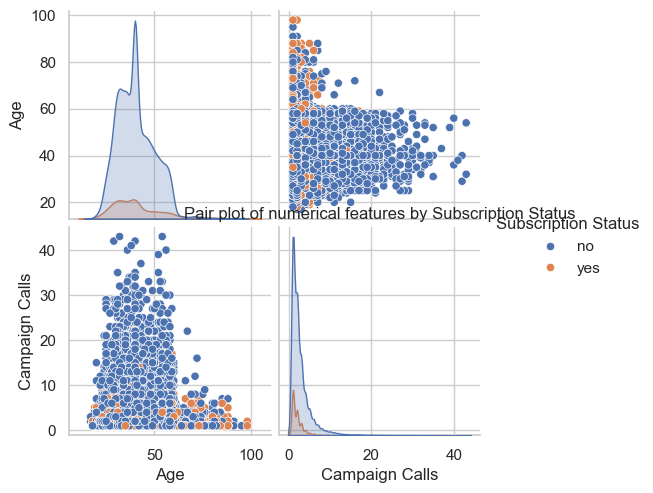

In [130]:
# Perform Bivariate analysis on the numerical features using pair plots
def plot_pair_plots(df, target_column):
    """
    This function performs bivariate analysis on numerical features using pair plots.
    """
    # Set the style of seaborn
    sns.set_theme(style="whitegrid")

    # Create a pair plot for the numerical features
    sns.pairplot(df, hue=target_column)
    plt.title(f"Pair plot of numerical features by {target_column}")
    plt.show()

# Run plot_pair_plots
plot_pair_plots(df, target_column_discrete)

#### Findings:
Results from bivariate analysis of numerical columns

| Numerical Column | Feature Engineering options  |
| ------------- | ------------- | 
|Age | Distributions for both subscription value have right skewness with tail to the right. **Transforming** 'Age' into age range into a new column 'Age Group' will allow the analysis to be more effective. | 
|Campaign Calls | From the plot, there seems to be some positive subscription for age > 50, even though the number of calls are high for age < 50. However, the effectiveness reduces after > 10 calls. To **remove outliers** using IQR method. |

The previous section aims to perform preliminary data preparation, such as:
  * Removal of duplicates
  * Converting to lowercase
  * Handling negative
  * Handling missing values
  * Renaming row values to more meaning description

The following section looks at performing feature engineering, such as:
  * Redundant Feature removal
  * Removal of outliers
  * Creating new features columns
  * Categorical binning
  * Performing correlation

Dropping columns that are not useful for the analysis

* 'Contact Method' can be removed, since no information of other types of communication is given and both celluar and telephone are voice calls. The assumption is the bank will continue use voice calls for prospecting.

In [131]:
# Dropping column Contact Method that are not useful for the analysis
if 'Contact Method' in df.columns:
	df.drop(columns=['Contact Method'], inplace=True)
	print("Removed 'Contact Method' column from the dataframe.")
else:
	print("Column 'Contact Method' not found in the dataframe. No column removed.")

Removed 'Contact Method' column from the dataframe.


Removal of outliers from 'Campaign Calls'

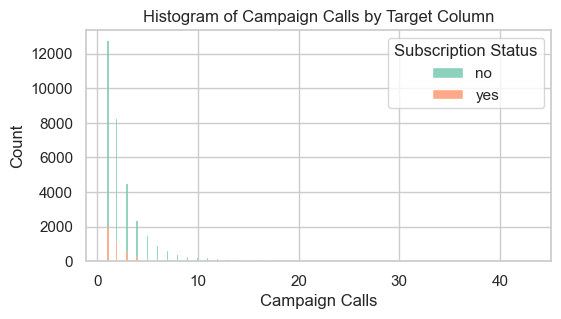

In [132]:
# Plot the Campaign Calls column with the target column, using a histogram
plt.figure(figsize=(6, 3))
sns.histplot(data=df, x='Campaign Calls', hue=target_column_discrete, multiple='stack', palette='Set2')
plt.title('Histogram of Campaign Calls by Target Column')
plt.xlabel('Campaign Calls')
plt.ylabel('Count')
plt.show()

#### Findings:

From the Campaign Calls, there are few calls that are over 10. The outliers should be removed.

In [133]:
# Use IQR method to remove outliers from the Campaign Calls column, using threshold_for_outlier_removal from config.yaml
if 'threshold_for_outlier_removal' in config:
    threshold = config['threshold_for_outlier_removal']['Campaign Calls']  # Extract the threshold for 'Campaign Calls'
    df = outliers_for_removal(df, 'Campaign Calls', threshold=threshold, lower_bound=False, upper_bound=True)

Lower bound for outliers in Campaign Calls: 1
Upper bound for outliers in Campaign Calls: 6.0
Removed outliers from the column: Campaign Calls, with threshold: 1.5
..............................


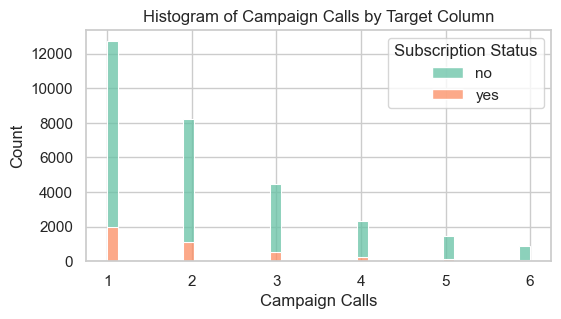

In [134]:
# Plot the Campaign Calls column with the target column, using a histogram
plt.figure(figsize=(6, 3))
sns.histplot(data=df, x='Campaign Calls', hue=target_column_discrete, multiple='stack', palette='Set2')
plt.title('Histogram of Campaign Calls by Target Column')
plt.xlabel('Campaign Calls')
plt.ylabel('Count')
plt.show()

#### Findings:
From the plot of Campaign Calls, making more than 1 call has a positive outcome too.

For Marital Status, rename 'divorced' and 'single' as 'not married'

* This will reduce the dimension of column 'Marital Status' to indicate a binary quality:
  * married
  * not married
  
This will remove any bias for divorced status, making the machine learning model more **explainable**.

In [135]:
# For Marital Status, rename 'divorced' and 'single' as 'not married'
df['Marital Status'] = df['Marital Status'].replace({'divorced': 'not married', 'single': 'not married'})
print("Renamed 'divorced' and 'single' as 'not married' in Marital Status column.")

Renamed 'divorced' and 'single' as 'not married' in Marital Status column.


Check for outliers in column 'Age'

In [136]:
# Check the Statistics of the column 'Age' in the dataframe
print("Statistics of the column 'Age':")
print(df['Age'].describe())
print_separator()

Statistics of the column 'Age':
count    30067.000000
mean        40.318788
std         10.127767
min         17.000000
25%         33.000000
50%         40.000000
75%         47.000000
max         98.000000
Name: Age, dtype: float64
..............................


#### Feature Engineering of 'Age' - Remap

For 'Age', remap the row values to the following groups:
* 'Twenties' for age <30
* 'Thirties' for age <40
* 'Forties' for age <50
* 'Fifties' for age <60
* 'Above Sixties' for age 60 and above

In [137]:
# Feature Engineering for Age by creating a new feature 'Age Group'
def age_group(age):
    """
    This function categorizes age into groups.
    """
    if age < 30:
        return 'Twenties'
    elif age < 40:
        return 'Thirties'
    elif age < 50:
        return 'Forties'
    elif age < 60:
        return 'Fifties'
    else:
        return 'Above Sixties'

In [138]:
# Check if the 'Age' column exists in the dataframe before creating the 'Age Group' feature
if 'Age' in df.columns:
	# Call the function to create a new feature 'Age Group'
	df['Age Group'] = df['Age'].apply(age_group)
	print("Added 'Age Group' column to the dataframe.")

	# Drop the 'Age' column from the dataframe
	df.drop(columns=['Age'], inplace=True)

else:
	print("The 'Age' column does not exist in the dataframe.")

# Check the datatype of the 'Age Group' column
print("Data type of 'Age Group' column: ", df['Age Group'].dtype)

Added 'Age Group' column to the dataframe.
Data type of 'Age Group' column:  object


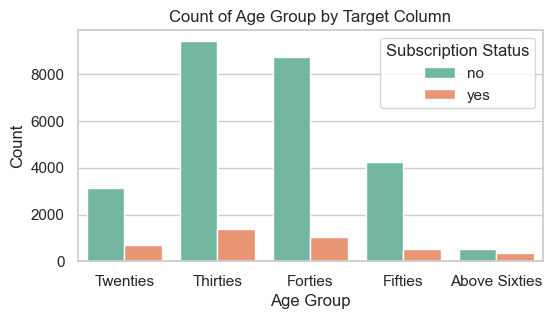

In [139]:
# For Age Group, plot the bar plot of the column Age Group, wrt to the target column
plt.figure(figsize=(6, 3))
sns.countplot(data=df, x='Age Group', hue=target_column_discrete, order=['Twenties', 'Thirties', 'Forties', 'Fifties', 'Above Sixties'], palette='Set2')
plt.title('Count of Age Group by Target Column')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title=target_column_discrete)
plt.show()


Detecting Missing Values

In [140]:
# Check for missing values in the dataframe, print the column name, the number of missing values and the percentage of missing values
df.isnull().sum()

Occupation                 0
Marital Status             0
Education Level            0
Credit Default             0
Housing Loan           17114
Personal Loan           3511
Campaign Calls             0
Subscription Status        0
Previous Contact           0
Age Group                  0
dtype: int64

In [141]:
# Print missing values of 'Housing Loan' and their percentage
print("Missing values in 'Housing Loan' column: ", df['Housing Loan'].isnull().sum())
print("Percentage: ", round(df['Housing Loan'].isnull().sum()/df.shape[0]*100, 2), "%")
print_separator()
# Print missing values of 'Personal Loan' and their percentage
print("Missing values in 'Personal Loan' column: ", df['Personal Loan'].isnull().sum())
print("Percentage: ", round(df['Personal Loan'].isnull().sum()/df.shape[0]*100, 2), "%")
print_separator()
print("Total missing values in 'Housing Loan' and 'Personal Loan' columns: ", df['Housing Loan'].isnull().sum() + df['Personal Loan'].isnull().sum())


Missing values in 'Housing Loan' column:  17114
Percentage:  56.92 %
..............................
Missing values in 'Personal Loan' column:  3511
Percentage:  11.68 %
..............................
Total missing values in 'Housing Loan' and 'Personal Loan' columns:  20625


#### Findings

High counts of missing values for both Housing Loan & Personal Loan  

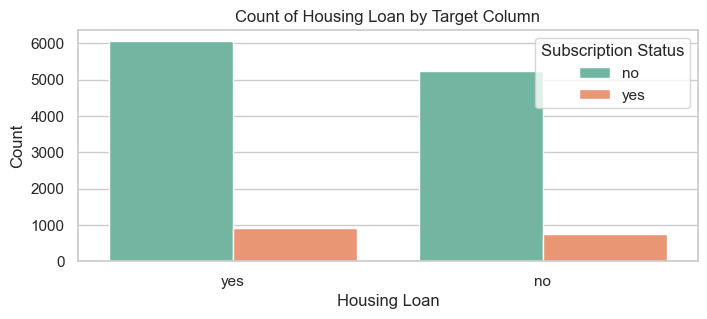

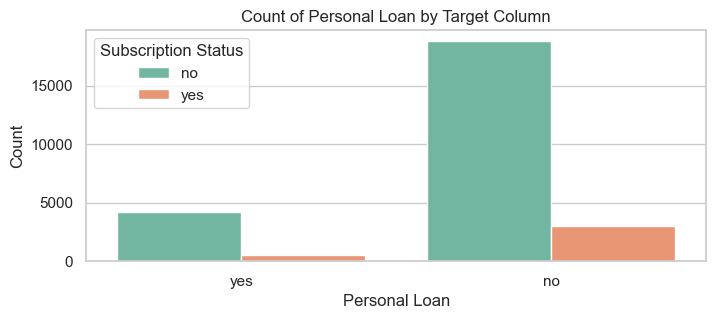

In [142]:
# Plot bar chart of the categorical for Housing Loan and Personal Loan, wrt to the target column
plt.figure(figsize=(8, 3))
sns.countplot(data=df, x='Housing Loan', hue=target_column_discrete, palette='Set2', order=['yes', 'no'])
plt.title('Count of Housing Loan by Target Column')
plt.xlabel('Housing Loan')
plt.ylabel('Count')
plt.legend(title=target_column_discrete)
plt.show()

# Plot bar chart of the categorical for Housing Loan and Personal Loan, wrt to the target column
# Fill NaN values in the 'Personal Loan' column with 'unknown' for visualization
df['Personal Loan'] = df['Personal Loan'].fillna('unknown')

plt.figure(figsize=(8, 3))
sns.countplot(data=df, x='Personal Loan', hue=target_column_discrete, palette='Set2', order=['yes', 'no'])
plt.title('Count of Personal Loan by Target Column')
plt.xlabel('Personal Loan')
plt.ylabel('Count')
plt.legend(title=target_column_discrete)
plt.show()

#### Feature Engineering of 'Housing Loan' and 'Personal Loan' - Remap
Since there is no indication of the loan amount for both the Housing Loan and Personal Loan, these feature can be combined to form a new feature that indicates that the clients have some existing loans.

New feature 'On Loan' will have a 'yes' if Housing Loan OR Personal Loan has a 'yes'
New feature 'On Loan' will have a 'no' if Housing Loan AND Personal Loan has a 'no'
New feature 'On Loan' will have a 'unknown' if Housing Loan AND Personal Loan has a 'unknown'

In [143]:
# Create a new feature that indicates that the client has existing loans.
from prompt_toolkit import print_formatted_text

if 'On Loan' not in df.columns:
	if 'Housing Loan' in df.columns and 'Personal Loan' in df.columns:
		# Create the 'On Loan' column
		# New feature 'On Loan' will have a 'yes' if Housing Loan OR Personal Loan has a 'yes'
		# New feature 'On Loan' will have a 'no' if Housing Loan AND Personal Loan has a 'no'
		# New feature 'On Loan' will have a 'unknown' if Housing Loan AND Personal Loan has a 'unknown'
		df['On Loan'] = np.where((df['Housing Loan'] == 'yes') | (df['Personal Loan'] == 'yes'), 'yes', 
			np.where((df['Housing Loan'] == 'no') & (df['Personal Loan'] == 'no'), 'no', 'unknown'))
		
		# Print the status of the 'On Loan' column
		print("Created the 'On Loan' column.")

		# Drop the 'Housing Loan' and 'Personal Loan' columns from the dataframe
		df.drop(columns=['Housing Loan', 'Personal Loan'], inplace=True)
		print("Removed 'Housing Loan' and 'Personal Loan' columns from the dataframe.")
else:
	print("The 'On Loan' column already exists in the dataframe. No column created.")


Created the 'On Loan' column.
Removed 'Housing Loan' and 'Personal Loan' columns from the dataframe.


In [144]:
# For 'On Loan', for each unique value, print its name, the count and the percentage
print("Unique values in 'On Loan' column:")
for col in df['On Loan'].unique():
    count = df[df['On Loan'] == col].shape[0]
    percentage = round(count/df.shape[0]*100, 2)
    print(f"'{col}': {count}, {percentage}%")

print_separator()
# Print missing values of 'On Loan' and the percentage
print("Missing values in 'On Loan' column: ", df['On Loan'].isnull().sum())
print("Percentage: ", round(df['On Loan'].isnull().sum()/df.shape[0]*100, 2), "%")

Unique values in 'On Loan' column:
'yes': 10576, 35.17%
'no': 4505, 14.98%
'unknown': 14986, 49.84%
..............................
Missing values in 'On Loan' column:  0
Percentage:  0.0 %


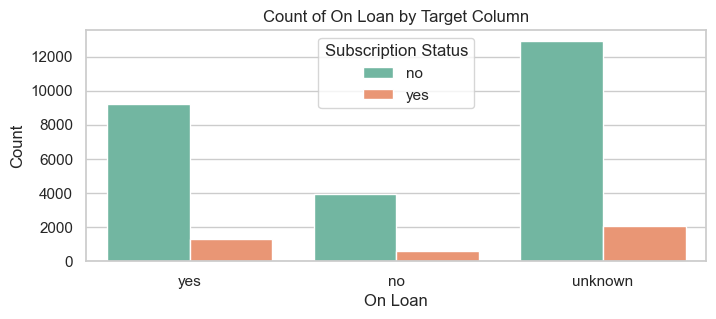

In [145]:
# Plot bar chart of the categorical for On Loan, wrt to the target column
plt.figure(figsize=(8, 3))
sns.countplot(data=df, x='On Loan', hue=target_column_discrete, palette='Set2')
plt.title('Count of On Loan by Target Column')
plt.xlabel('On Loan')
plt.ylabel('Count')
plt.legend(title=target_column_discrete)
plt.show()

#### Findings:
From the plot of 'On Loan', the transfomation reduces the worst case of Missing values (as seen in 'Housing Loan'), from 56.92 % to 49.84% (reclassify as 'unknown' in the new feature), this number is still significant.

Similar to 'Credit Default', the 'unknown' can be renamed as 'undisclosed' for better data analysis, instead of imputting with a 'yes' or 'no' or considering row removal which may impact the dataset performance. 


In [146]:
# Rename the 'unknown' value on 'On Loan' column to 'undisclosed'
df['On Loan'] = df['On Loan'].replace('unknown', 'undisclosed')
print("Renamed 'unknown' value to 'undisclosed' in 'On Loan' column.")

Renamed 'unknown' value to 'undisclosed' in 'On Loan' column.


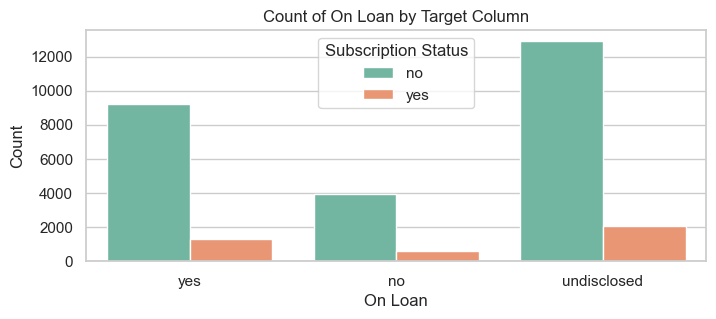

In [147]:
# Plot bar chart of the categorical for On Loan, wrt to the target column
plt.figure(figsize=(8, 3))
sns.countplot(data=df, x='On Loan', hue=target_column_discrete, palette='Set2')
plt.title('Count of On Loan by Target Column')
plt.xlabel('On Loan')
plt.ylabel('Count')
plt.legend(title=target_column_discrete)
plt.show()

#### Feature Engineering of 'Education Level' - Remap

* Feature Engineering for Education Level are mapped into 3 groups: primary, secondary and tertiary

In [148]:
# Feature Engineering for Education are mapped into 3 groups, as specified by Education_Group in the config.yaml file:

def education_level(education):
    """
    This function categorizes the education level into groups,
    as specified by Education_Group in the config.yaml file.
    """
    if education in config['Education_Group']['Primary']:
        return 'primary'
    elif education in config['Education_Group']['Secondary']:
        return 'secondary'
    elif education in config['Education_Group']['Tertiary']:
        return 'tertiary'
    else:
        return 'others'

# Print the list of education levels
print("Primary: ", config['Education_Group']['Primary'])
print("Secondary: ", config['Education_Group']['Secondary'])
print("Tertiary: ", config['Education_Group']['Tertiary'])


Primary:  ['illiterate', 'basic.4y', 'basic.6y']
Secondary:  ['basic.9y', 'high.school']
Tertiary:  ['professional.course', 'university.degree']


In [149]:
# Check if the 'Education Level' column exists in the dataframe before creating the 'Education Group' feature as in config.yaml
if 'Education Level' in df.columns:
    # Call the function to create a new feature 'Education Group'
    df['Education Group'] = df['Education Level'].apply(education_level)
    print("Added 'Education Group' column to the dataframe.")

    # Drop the 'Education Level' column from the dataframe
    df.drop(columns=['Education Level'], inplace=True)
    print("Removed 'Education Level' column from the dataframe.")
else:
    print("The 'Education Level' column does not exist in the dataframe.")



Added 'Education Group' column to the dataframe.
Removed 'Education Level' column from the dataframe.


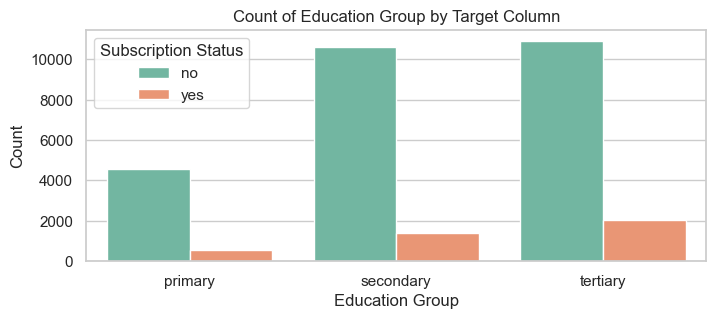

In [150]:
# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns

# For Education Group, plot the bar plot of the column Education Group, wrt to the target column
# plot starting with primary, secondary, tertiary
plt.figure(figsize=(8, 3))
sns.countplot(data=df, x='Education Group', hue=target_column_discrete, palette='Set2', order=['primary', 'secondary', 'tertiary'])
plt.title('Count of Education Group by Target Column')
plt.xlabel('Education Group')
plt.ylabel('Count')
plt.legend(title=target_column_discrete)
plt.show()


#### Feature Engineering 'Occupation' - Remap

In [151]:
# Feature Engineering for Occupation are mapped into 3 groups, as specified by Occupation_Group in the config.yaml file:

def Occupation_level(occupation):
    """
    This function categorizes the occupation level into groups, 
    as specified by Occupation_Group in the config.yaml file.
    """
    if occupation in config['Occupation_Group']['Blue_Collar']:
        return 'blue collar'
    elif occupation in config['Occupation_Group']['White_Collar']:
        return 'white collar'
    elif occupation in config['Occupation_Group']['Grey_Collar']:
        return 'grey collar'
    else:
        return 'other'

# Print the list of Occupation_level
print("Blue Collar Occupations: ", config['Occupation_Group']['Blue_Collar'])
print("White Collar Occupations: ", config['Occupation_Group']['White_Collar'])
print("Grey Collar Occupations: ", config['Occupation_Group']['Grey_Collar'])


Blue Collar Occupations:  ['blue-collar', 'technician', 'services']
White Collar Occupations:  ['admin.', 'entrepreneur', 'management', 'self-employed']
Grey Collar Occupations:  ['housemaid', 'unemployed', 'student', 'retired']


In [152]:
# Check if the 'Occupation' column exists in the dataframe before creating the 'Occupation Group' feature
if 'Occupation' in df.columns:
    # Call the function to create a new feature 'Occupation Group'
    df['Occupation Group'] = df['Occupation'].apply(Occupation_level)
    print("Added 'Occupation Group' column to the dataframe.")

    # Drop the 'Occupation' column from the dataframe
    df.drop(columns=['Occupation'], inplace=True)
    print("Removed 'Occupation' column from the dataframe.")
else:
    print("The 'Occupation' column does not exist in the dataframe.")

Added 'Occupation Group' column to the dataframe.
Removed 'Occupation' column from the dataframe.


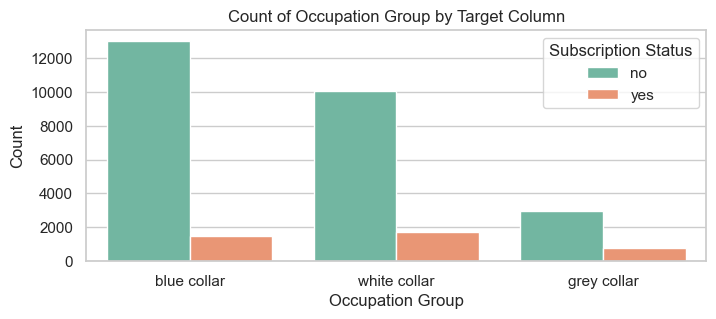

In [153]:
# For Occupation Group, plot the bar plot of the column Occupation Group, wrt to the target column
plt.figure(figsize=(8, 3))
sns.countplot(data=df, x='Occupation Group', hue=target_column_discrete, palette='Set2')
plt.title('Count of Occupation Group by Target Column')
plt.xlabel('Occupation Group')
plt.ylabel('Count')
plt.legend(title=target_column_discrete)
plt.show()

Perform Spearman correlation

Categorical columns:  ['Marital Status', 'Credit Default', 'Previous Contact', 'Age Group', 'On Loan', 'Education Group', 'Occupation Group']
Spearman correlation matrix:                    Marital Status  Credit Default  Previous Contact  Age Group  \
Marital Status          1.000000       -0.121396          0.025121   0.016963   
Credit Default         -0.121396        1.000000         -0.091543  -0.012309   
Previous Contact        0.025121       -0.091543          1.000000   0.035788   
Age Group               0.016963       -0.012309          0.035788   1.000000   
On Loan                 0.011508        0.012320          0.009771  -0.000867   
Education Group        -0.081626        0.075179          0.015652  -0.001272   
Occupation Group        0.031126       -0.079934          0.096952   0.025521   

                   On Loan  Education Group  Occupation Group  
Marital Status    0.011508        -0.081626          0.031126  
Credit Default    0.012320         0.075179        

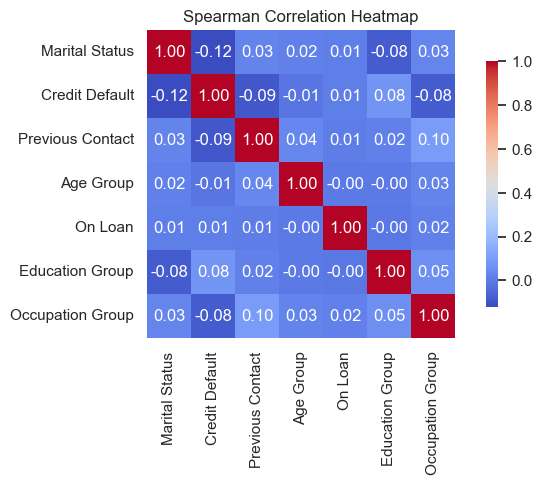

In [154]:
# List the categorical columns in the dataframe, less the target column
categorical_columns = df.select_dtypes(include='object').columns.tolist()
categorical_columns.remove(target_column_discrete)
print("Categorical columns: ", categorical_columns)

# Calculate the Spearman correlation less the target column
correlation_matrix = df[categorical_columns].apply(lambda x: pd.factorize(x)[0]).corr(method='spearman')    
print("Spearman correlation matrix: ", correlation_matrix)
print_separator()
# Plot the heatmap of the Spearman correlation
plt.figure(figsize=(8, 4))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Spearman Correlation Heatmap')
plt.show()

#### Findings:

Key Observations from Spearman correlation:

| Features | Observation |
| --- | --- |
|Marital Status & Age Group (0.1266)|Slight positive correlation - older individuals may have different marital patterns.|
|Marital Status & Credit Default (-0.1092)| Weak negative correlation - marital status may have some effect on credit reliability.|
|Previous Contact & Age Group (0.0814)| Slight positive correlation - older individuals might react differently.|
|Occupation Group & Previous Contact (0.0981)| Mild positive correlation - certain occupations may receive more targeted outreach.|
|Education Group & Credit Default (0.0737)| Weak positive correlation - education might slightly impact credit behavior.|
|On Loan Status & Other Variables| Relatively weak correlations - with other categorical variables.|




Perform Chi-Square test  
* Measures for significant association between two categorical variables
* for p-value < 0.05, the variables are dependent. **To retain.**
* for p-value > 0.05, the variables are independent. **To drop.**

In [155]:
import scipy.stats as stats
# Perform Chi-Square test for independence between categorical features and target column

def chi_square_test(df, categorical_columns, target_column):
    """
    This function performs Chi-Square test for independence between categorical features and target column.
    """
    print(f"Target: {target_column}")
    for col in categorical_columns:
        if col != target_column:
            contingency_table = pd.crosstab(df[col], df[target_column])
            chi2, p, _, _ = stats.chi2_contingency(contingency_table)
            print(f"Chi-Square test for {col}:")
            print(f"Chi2: {chi2:,.3f}, p-value: {p:,.3f}")
            if p < 0.05:
                print(f"The variables {col} with Target are dependent.")
            else:
                print(f"The variables {col} with Target are independent.")
            print_separator()
# Get the categorical columns from the dataframe
categorical_columns = df.select_dtypes(include='object').columns.tolist()
# Run chi_square_test function
chi_square_test(df, categorical_columns, target_column_discrete)

Target: Subscription Status
Chi-Square test for Marital Status:
Chi2: 33.038, p-value: 0.000
The variables Marital Status with Target are dependent.
..............................
Chi-Square test for Credit Default:
Chi2: 379.266, p-value: 0.000
The variables Credit Default with Target are dependent.
..............................
Chi-Square test for Previous Contact:
Chi2: 3,092.815, p-value: 0.000
The variables Previous Contact with Target are dependent.
..............................
Chi-Square test for Age Group:
Chi2: 706.356, p-value: 0.000
The variables Age Group with Target are dependent.
..............................
Chi-Square test for On Loan:
Chi2: 10.791, p-value: 0.005
The variables On Loan with Target are dependent.
..............................
Chi-Square test for Education Group:
Chi2: 112.946, p-value: 0.000
The variables Education Group with Target are dependent.
..............................
Chi-Square test for Occupation Group:
Chi2: 327.931, p-value: 0.000
The 

#### Findings:

Key Observations from Chi-Square test:

Dependent variables (significant association with Subscription Status):
 
|  Dependent variable  |  Target  |
| --- | --- |
|Marital Status| Dependent  |
|Credit Default| Dependent: strong association or significantly influences   |
|Previous Contact| Dependent: very strong association   |
|Age Group| Dependent: strong association or strong relationship  |
|Education Group| Dependent  |
|Occupation Group| Dependent: strongly affects  |
|On Loan status| Dependent   |


Final stretch... housekeeping and relook at the data structures for each feature.

In [156]:
# Relook at the data types of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30067 entries, 0 to 41186
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Marital Status       30067 non-null  object
 1   Credit Default       30067 non-null  object
 2   Campaign Calls       30067 non-null  int64 
 3   Subscription Status  30067 non-null  object
 4   Previous Contact     30067 non-null  object
 5   Age Group            30067 non-null  object
 6   On Loan              30067 non-null  object
 7   Education Group      30067 non-null  object
 8   Occupation Group     30067 non-null  object
dtypes: int64(1), object(8)
memory usage: 2.3+ MB


In [157]:
# Print the data types of each feature, its unique values, number of unique values 
# as well as missing values
for col in df.columns:
    print(f"Column name: {col}")
    print(f"Data type: {df[col].dtype}")
    print(f"Number of unique values: {df[col].nunique()}")
    print(f"Unique values: {df[col].unique()}")
    print(f"Number of missing values: {df[col].isnull().sum()}")
    print_separator()

Column name: Marital Status
Data type: object
Number of unique values: 2
Unique values: ['married' 'not married']
Number of missing values: 0
..............................
Column name: Credit Default
Data type: object
Number of unique values: 2
Unique values: ['no' 'undisclosed']
Number of missing values: 0
..............................
Column name: Campaign Calls
Data type: int64
Number of unique values: 6
Unique values: [1 4 2 3 5 6]
Number of missing values: 0
..............................
Column name: Subscription Status
Data type: object
Number of unique values: 2
Unique values: ['no' 'yes']
Number of missing values: 0
..............................
Column name: Previous Contact
Data type: object
Number of unique values: 2
Unique values: ['no prior contact' 'prior contact']
Number of missing values: 0
..............................
Column name: Age Group
Data type: object
Number of unique values: 5
Unique values: ['Fifties' 'Thirties' 'Twenties' 'Forties' 'Above Sixties']
Numbe

Re-checking Missing Values

In [158]:
# Check for missing values in the dataframe, print the column name, the number of missing values and the percentage of missing values
df.isnull().sum()

Marital Status         0
Credit Default         0
Campaign Calls         0
Subscription Status    0
Previous Contact       0
Age Group              0
On Loan                0
Education Group        0
Occupation Group       0
dtype: int64

Re-checking Duplicate Values

In [159]:
# Find the duplicate rows in the dataframe and print the number of duplicate rows
# Check for duplicates in the dataframe
print("Number of duplicates: ", df.duplicated().sum())
# Find the row count of the df
print("Number of rows: ", df.shape[0])
# Calculate the percentage of duplicates to 2 decimal places
# Print the percentage of duplicates to 2 decimal places
print("Percentage of duplicates: ", round(df.duplicated().sum()/df.shape[0]*100, 2), "%")
print_separator()

# Remove duplicate rows from the dataframe
df.drop_duplicates(inplace=True)
# Print the number of duplicate rows after removal
print("Number of duplicates after removal: ", df.duplicated().sum())

Number of duplicates:  26391
Number of rows:  30067
Percentage of duplicates:  87.77 %
..............................
Number of duplicates after removal:  0


Evaluating the dataframe EDA analysis process

In [160]:
# Calculate final number of rows and columns in the dataframe
final_row_count_at_eda = len(df)
final_column_count_at_eda = len(df.columns)

print(f"Initial number of columns in the dataframe: {initial_column_count}\n"
      f"After EDA, final number of columns in the dataframe: {final_column_count_at_eda}\n"
      f"Initial Number of rows: {initial_row_count}\n"           
      f"After EDA, final Number of rows: {final_row_count_at_eda}\n"           
      f"Percentage data loss : {((initial_row_count - final_row_count_at_eda) / initial_row_count) * 100:.1f}%")

Initial number of columns in the dataframe: 12
After EDA, final number of columns in the dataframe: 9
Initial Number of rows: 41188
After EDA, final Number of rows: 3676
Percentage data loss : 91.1%


**These are the insights**

1. The data was read from a SQLite database as a df.

2. Exploratory Data Analysis (EDA) was done to understand the data.

3. The data was cleaned by:
    - dropping: Client ID
    - understand the data structures
    - check for missing values
    - converting categorical values to lowercase
    - renaming 'cell' to 'cellular'
    - replacing extreme values with range-in mean
    - remove rows with 'unknown' values that contains <5% of dataset
    - rename row values with alternate naming (Credit Default: 'unknown' = 'undisclosed')
    - rename '999' and '0' in Previous Contact Day as 'no prior contact'
    - from the visualisation with bar plots and histogram, perform the following:
      - drop the features:
        - Contact Method
      - remove outlier of Campaign Calls
      - rename row values with alternate naming (Marital Status: 'divorced' and 'single' = 'married')
      - Feature Engineering of 'Age' to new feature 'Age Group'
      - Feature Engineering of 'Housing Loan' and 'Personal Loan' to new feature 'On Loan'
      - Feature Engineering of 'Education Level' to new feature 'Education Group'
      - Feature Engineering 'Occupation' to new feature 'Occupation Group'
    - Calculate the Spearman correlation
    - Calculate the chi_square_test
  
4. The distribution of the data was visualized using boxplots and histograms.
   
5. Various Feature Engineering methods were attempted.
   
6. The Spearman correlation and Chi-Square test were calculated to check for multicollinearity.

7.  The cleaned data was saved to a CSV file 'eda_completed.csv'.


Saving the completed EDA

In [161]:
# The data is now ready for further analysis and modeling.
# Save the cleaned data to a new csv - agri_cleaned_final.csv
df.to_csv('./data/eda_completed.csv', index=False)

#### EDA completed

In [162]:
# EDA completed
print_separator()
print("Exploratory Data Analysis (EDA) completed")

..............................
Exploratory Data Analysis (EDA) completed


#### Perform Classification

In [163]:
# Import pandas
import pandas as pd
import logging
import yaml

# Import libraries requiredfor classification models
# from src.classification_models import classification_setup
# from src.classification_models import classification_preprocessor
# from src.classification_models import classification_models_baseline
# from src.classification_models import classification_models_hyperparameters

In [164]:
# Open eda_completed.csv as a dataframe for model training
df = pd.read_csv('./data/eda_completed.csv')

# Print the shape of the dataframe
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3676 entries, 0 to 3675
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Marital Status       3676 non-null   object
 1   Credit Default       3676 non-null   object
 2   Campaign Calls       3676 non-null   int64 
 3   Subscription Status  3676 non-null   object
 4   Previous Contact     3676 non-null   object
 5   Age Group            3676 non-null   object
 6   On Loan              3676 non-null   object
 7   Education Group      3676 non-null   object
 8   Occupation Group     3676 non-null   object
dtypes: int64(1), object(8)
memory usage: 258.6+ KB
None


In [165]:
# Import the yaml module
import yaml
import os

# Load configuration from a YAML file as encoding='utf-8
config_path = './src/config.yaml'

if os.path.exists(config_path):
    with open(config_path, 'r', encoding='utf-8') as file:  # open the config.yaml file
        config = yaml.safe_load(file)  # load the configuration
    print ("config.yaml file loaded")
else:
    print ("config.yaml file not found")

config.yaml file loaded


In [ ]:
# Define or import the classification_setup function
def classification_setup(config):
    """
    This function performs the following steps:
        1. Load the dataset from a CSV file.
        2. Print the shape of the dataframe.
        3. Call the classification_preprocessor function to preprocess the data.
    """

    # Requires Python 3.11.0
    # Standard library imports
    import logging
    from typing import Any, Dict, Tuple
    import yaml
    import ruamel.yaml

    # Related third-party imports
    import numpy as np
    import pandas as pd

    # Define the mapping for classification models
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.svm import SVC
    from sklearn.tree import DecisionTreeClassifier

    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.model_selection import train_test_split
    from sklearn.model_selection import GridSearchCV

    #########################################################################################
    # print_separator() - prints a separator to the console for ease of reading
    #########################################################################################
    def print_separator():
        """
        This function performs the following steps:
            1. Print a separator line to the console.
        """
        print("-"*30)

    # Map model names to their corresponding classes
    classification_model_classes = {
        'LogisticRegression': LogisticRegression,
        'KNeighborsClassifier': KNeighborsClassifier,
        'RandomForestClassifier': RandomForestClassifier,
        'SVC': SVC,
        'GradientBoostingClassifier': GradientBoostingClassifier,
        'AdaBoostClassifier': AdaBoostClassifier,
        'DecisionTreeClassifier': DecisionTreeClassifier
    }
    
    # put the following code in a function
    def get_classification_models():
        """
        This function returns a dictionary of classification models.
        """
        models = {}
        for model_name in classification_models:
            # Dynamically create the model object and add it to the models dictionary
            if model_name in classification_model_classes:  # classification_model_classes is defined in CELL INDEX: 3
                models[model_name] = classification_model_classes[model_name]()
                # List the model name and its object
                # print(f"Model mapping: {model_name}, Model object: {models[model_name]}")
 
        return models
    
    # print_separator()
    # Initialize classification_models from the config dictionary
    classification_models = config.get('classification_models', [])

    # Print model list
    if classification_models:
        classification_models = get_classification_models()
        # Print the classification models
        # print('The classification models are:', classification_models)
    else:
        print("No classification models to process.")

    # print_separator()
    # Get "classification_target" from config.yaml
    if 'classification_target' in config:
        target_column_discrete = config['classification_target'] 
        # print('Target column for Classification:', target_column_discrete)
    else:
        print("Error: 'classification_target' key is missing in the configuration.")
    
    # print_separator()
    # Print type of hyperparameters performance:
    # print("Classification: Optimum or fast tuning performance set to:", config['classification_tuning_performance_set_optimum'])

    # Get the hyperparameters from the config.yaml file
    if config.get('classification_tuning_performance_set_optimum') == 1:
        # If the key exists, set hyperparameters_classification to classification_hyperparameters_fast
        hyperparameters_classification = config['classification_hyperparameters_fast']
    elif config.get('classification_tuning_performance_set_optimum') == 2:
        # If the key exists, set hyperparameters_classification to classification_hyperparameters_slow
        hyperparameters_classification = config['classification_hyperparameters_slow']
    else:
        print("Error: 'classification_tuning_performance_set_optimum' key is missing or invalid in the configuration.")

    print("Classification: Optimum tuning performance set to:", hyperparameters_classification)
    # Print hyperparameters values
    # print('Hyperparameters are:')
    # print('Models:', hyperparameters_classification)

    # print_separator()
    # From config.yaml, the values in "classification_metrics" are the metrics to be used for classification
    # Get the classification metrics from the config.yaml file
    if 'classification_metrics' in config:
        classification_metrics = config['classification_metrics']
        # print(f"Metrics used: {classification_metrics}")
    else:
        print("Error: 'classification_metrics' key is missing in the configuration.")
        return

    # print_separator()

    return (target_column_discrete, 
            classification_models, 
            classification_model_classes, 
            hyperparameters_classification, 
            classification_metrics)

# def classification_setup(config)

In [167]:
def classification_setup_results (target_column_discrete, classification_models, hyperparameters_classification, classification_metrics, config):
    """
    This function returns the results of the classification setup.
    """
    def print_separator():
        """
        This function performs the following steps:
            1. Print a separator line to the console.
        """
        print("-"*30)
    
    # Check the returned values
    # Print the classification target, models, hyperparameters_classification and metrics
    print(f"Target column: {target_column_discrete}")
    print_separator()
    print(f"Classification models: {classification_models}")
    print_separator()
    print(f"Classification tuning optimum is: {config['classification_tuning_performance_set_optimum']}")
    print(f"Hyperparameters classification: {hyperparameters_classification}")
    print_separator()
    print(f"Classification metrics: {classification_metrics}")

    return

# def classification_setup_results (target_column_discrete, classification_models, hyperparameters_classification, classification_metrics, config)

In [168]:
# Call function: classification_setup
target_column_discrete, classification_models, classification_model_classes, hyperparameters_classification, classification_metrics = classification_setup(config)

# Call function: classification_setup_results
classification_setup_results(target_column_discrete, classification_models, hyperparameters_classification, classification_metrics, config)


Classification: Optimum tuning performance set to: {'LogisticRegression': {'classifier__C': [0.1, 1.0]}, 'KNeighborsClassifier': {'classifier__n_neighbors': [3, 5]}, 'RandomForestClassifier': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [None, 10]}, 'SVC': {'classifier__C': [0.1, 1.0], 'classifier__kernel': ['linear', 'rbf']}, 'GradientBoostingClassifier': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [3, 5]}}
Target column: Subscription Status
------------------------------
Classification models: {'LogisticRegression': LogisticRegression(), 'KNeighborsClassifier': KNeighborsClassifier(), 'RandomForestClassifier': RandomForestClassifier(), 'SVC': SVC(), 'GradientBoostingClassifier': GradientBoostingClassifier()}
------------------------------
Classification tuning optimum is: 1
Hyperparameters classification: {'LogisticRegression': {'classifier__C': [0.1, 1.0]}, 'KNeighborsClassifier': {'classifier__n_neighbors': [3, 5]}, 'RandomForestClassifier

In [169]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import logging

#########################################################################################
# The function classification_preprocessor is defined to preprocess the data for classification tasks.
#########################################################################################
def classification_preprocessor(df, config):
    """
    This function performs the following steps:
        1. Identifies the target column for classification
        2. Identifies the numerical columns
        3. Identifies the categorical columns
        4. Creates a column transformer with OneHotEncoder for categorical columns and StandardScaler for numerical columns
        5. Splits the data into training and testing sets
        6. Returns the training and testing sets and the column transformer
    """
   
    #########################################################################################
    # print_separator() - prints a separator to the console for ease of reading
    #########################################################################################
    def print_separator():
        """
        This function performs the following steps:
            1. Print a separator line to the console.
        """
        print("-"*30)


    logging.info("--- Identifying the target column for classification")
    target_column_discrete = config.get('classification_target', 'Subscription Status')
    # print("Target column for classification: ", target_column_discrete)

    logging.info("Data cleaning - showing initial data")
    # print_separator()

    logging.info("--- Identifying the numerical columns")
    # Identify numerical columns
    numerical_columns = df.select_dtypes(exclude=['object']).columns
    # print("Numerical columns: ", numerical_columns)
    
    # If target column is in numerical-columns, remove it
    numerical_columns = numerical_columns.difference([target_column_discrete])

    # print the numerical columns for verification
    print('Verifying Numerical columns: ', numerical_columns)
    # print_separator()

    logging.info("--- Identifying the categorical columns")
    # Identify categorical columns
    categorical_columns = df.select_dtypes(include=['object']).columns
    
    # If target column is in categorical, remove it
    categorical_columns = categorical_columns.difference([target_column_discrete])
    # print the categorical columns for verification
    print('Verifying Categorical_columns : ', categorical_columns)
    # print_separator()

    logging.info("--- Creating a column transformer with OneHotEncoder for categorical columns and StandardScaler for numerical columns")
    # Create a column transformer with OneHotEncoder for categorical columns and StandardScaler for numerical columns
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_columns),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)  # Added handle_unknown='ignore'
    ])

    logging.info("--- Splitting the data into training and testing sets")
    # Split the data into training and testing sets
    X = df.drop(target_column_discrete, axis=1)
    y = df[target_column_discrete]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    logging.info("--- Classification Preprocessor - Completed")

    return (target_column_discrete, 
            numerical_columns, 
            categorical_columns, 
            X_train, 
            X_test, 
            y_train, 
            y_test, 
            preprocessor)

# def classification_preprocessor(df, config)

In [170]:
def classification_preprocessor_results(target_column_discrete, df, numerical_columns, categorical_columns, X_train, X_test, y_train, y_test, preprocessor):
    """
    This function displays the preprocessor results.
    """
    print_separator
    print("<<< Classification Preprocessor Setup Results >>>")
    print_separator
    # Check the returned values
    print('The target column is:', target_column_discrete)
    print_separator()
    
    # Print the shape of the dataframe
    print('The number of rows in the dataset is:', df.shape[0])
    
    # Print the numerical columns for verification
    print('Verifying Numerical columns:', numerical_columns)
    
    # Print the categorical columns for verification
    print('Verifying Categorical columns:', categorical_columns)
    print_separator()
    
    # Print the shape of the training and testing sets
    print('X_train shape:', X_train.shape)
    print('X_test shape:', X_test.shape)
    print('y_train shape:', y_train.shape)
    print('y_test shape:', y_test.shape)
    print_separator()
    
    # Print preprocessor details
    print('Preprocessor:', preprocessor)
    print_separator()

    return (target_column_discrete, numerical_columns, categorical_columns, X_train, X_test, y_train, y_test, preprocessor)
# def classification_preprocessor_results(target_column_discrete, df, numerical_columns, categorical_columns, X_train, X_test, y_train, y_test, preprocessor)


In [171]:
# Call function: classification_preprocessor
target_column_discrete, numerical_columns, categorical_columns, X_train, X_test, y_train, y_test, preprocessor = classification_preprocessor(df, config)

# Call function: classification_preprocessor_result
classification_preprocessor_results(target_column_discrete, df, numerical_columns, categorical_columns, X_train, X_test, y_train, y_test, preprocessor)


# Display preprocessor
preprocessor

Verifying Numerical columns:  Index(['Campaign Calls'], dtype='object')
Verifying Categorical_columns :  Index(['Age Group', 'Credit Default', 'Education Group', 'Marital Status',
       'Occupation Group', 'On Loan', 'Previous Contact'],
      dtype='object')
<<< Classification Preprocessor Setup Results >>>
The target column is: Subscription Status
..............................
The number of rows in the dataset is: 3676
Verifying Numerical columns: Index(['Campaign Calls'], dtype='object')
Verifying Categorical columns: Index(['Age Group', 'Credit Default', 'Education Group', 'Marital Status',
       'Occupation Group', 'On Loan', 'Previous Contact'],
      dtype='object')
..............................
X_train shape: (2940, 8)
X_test shape: (736, 8)
y_train shape: (2940,)
y_test shape: (736,)
..............................
Preprocessor: ColumnTransformer(transformers=[('num', StandardScaler(),
                                 Index(['Campaign Calls'], dtype='object')),
            

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 Index(['Campaign Calls'], dtype='object')),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['Age Group', 'Credit Default', 'Education Group', 'Marital Status',
       'Occupation Group', 'On Loan', 'Previous Contact'],
      dtype='object'))])

In [172]:
# ###################################################################
# Perform the Classification modeling - getting the baesline
# ###################################################################
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

def classification_baseline(df, classification_models, preprocessor, X_train, X_test, y_train, y_test):
    """
    This function performs the following steps:
        1. Imports the required libraries
        2. Creates a dictionary of classification models
        3. Preprocesses the data for classification
        4. Creates a pipeline for each model
        5. Fits the pipeline to the training data
        6. Predicts the target on the testing data
        7. Calculates the metrics
        8. Returns the metrics dataframe
    """

    def print_separator():
        """
        This function performs the following steps:
            1. Print a separator line to the console.
        """
        print("-"*30)
        
    # Use the classification_models dictionary directly
    models = classification_models
    # print the dictionary of models
    print ('The classification models are:')
    print(models)
    print_separator()

    print("Part 1 - Baseline of Classification Models")
    print_separator()

    # Create an empty dictionary to store the metrics
    metrics = {}

    # For each model, calculate the metrics and store in the dictionary
    for name, model in models.items():
        # print the name of the model
        print("--- Model running: ", name)
        logging.info("--- 1. Creating a pipeline for the model")
        # Create a pipeline
        pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', model)])
        logging.info("--- 2. Fitting the pipeline to the training data")
        # Fit the pipeline to the training data
        pipeline.fit(X_train, y_train)
        logging.info("--- 3. Predicting the target on the testing data")
        # Predict the target on the testing data
        logging.info("--- 4. Calculating the metrics")
        y_pred = pipeline.predict(X_test)
        # Calculate the accuracy
        accuracy = accuracy_score(y_test, y_pred)
        # Calculate the precision
        precision = precision_score(y_test, y_pred, average='weighted')
        # Calculate the recall
        recall = recall_score(y_test, y_pred, average='weighted')
        # Calculate the F1 score
        f1 = f1_score(y_test, y_pred, average='weighted')
        # Store the metrics in the dictionary
        metrics[name] = [accuracy, precision, recall, f1]

        # Create a dataframe from the metrics dictionary
        logging.info("--- Creating a dataframe from the metrics dictionary")
        metrics_df = pd.DataFrame(metrics, index=['Accuracy', 'Precision', 'Recall', 'F1 Score'])

    # Print the metrics_tuned_df dataframe
    print(metrics_df)

    # Create a dataframe from the metrics dictionary
    logging.info("--- Creating a dataframe from the metrics dictionary")
    print_separator()
    metrics_df = pd.DataFrame(metrics, index=['Accuracy', 'Precision', 'Recall', 'F1 Score'])

    # Print the metrics dataframe
    print(metrics_df)

    print_separator()
    # Print the bext model based on the metrics
    # Print the best model based on F1 Score with 3 decimal places
    print("Best model based on F1 Score:", metrics_df.loc['F1 Score'].idxmax(), ", with a F1 Score of: ", round(metrics_df.loc['F1 Score'].max(), 3))

    # Print the hyperparameters of the best model
    print("Hyperparameters of the best model:")
    print(models[metrics_df.loc['F1 Score'].idxmax()])
    logging.info("--- Classification Baseline Models - Completed")

    # With the best model, print the confusion matrix
    # Get the best model
    best_model = metrics_df.loc['F1 Score'].idxmax()
    # Get the best model object
    best_model_object = models[best_model]
    # Create a pipeline with the best model
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', best_model_object)])
    # Fit the pipeline to the training data
    pipeline.fit(X_train, y_train)
    # Predict the target on the testing data
    y_pred = pipeline.predict(X_test)
    # Calculate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    # Create a confusion matrix display
    cmd = ConfusionMatrixDisplay(cm, display_labels=pipeline.classes_)
    # Plot the confusion matrix
    cmd.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {best_model}')
    plt.show()
    
    return metrics_df

# def classification_baseline(df, models):


In [173]:
# ###################################################################
# Perform the Classification modeling - getting the baesline
# ###################################################################
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

def classification_baseline_LogisticRegression(df, models):
    """
    This function performs the following steps:
        1. Imports the required libraries
        2. Creates a dictionary of classification models
        3. Preprocesses the data for classification
        4. Creates a pipeline for each model
        5. Fits the pipeline to the training data
        6. Predicts the target on the testing data
        7. Calculates the metrics
        8. Returns the metrics dataframe
    """

    def print_separator():
        """
        This function performs the following steps:
            1. Print a separator line to the console.
        """
        print("-"*30)
        
    # Use the classification_models dictionary directly
    models = classification_models
    # print the dictionary of models
    # print ('The classification models are:')
    # print(models)
    # print_separator()

    print("Quick run of Logistic Regression")
    print_separator()

    # Create an empty dictionary to store the metrics
    metrics = {}

    # For each model, calculate the metrics and store in the dictionary
    for name, model in models.items():
        # print the name of the model
        # print("--- Model running: ", name)
        logging.info("--- 1. Creating a pipeline for the model")
        # Create a pipeline
        pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', model)])
        logging.info("--- 2. Fitting the pipeline to the training data")
        # Fit the pipeline to the training data
        pipeline.fit(X_train, y_train)
        logging.info("--- 3. Predicting the target on the testing data")
        # Predict the target on the testing data
        logging.info("--- 4. Calculating the metrics")
        y_pred = pipeline.predict(X_test)
        # Calculate the accuracy
        accuracy = accuracy_score(y_test, y_pred)
        # Calculate the precision
        precision = precision_score(y_test, y_pred, average='weighted')
        # Calculate the recall
        recall = recall_score(y_test, y_pred, average='weighted')
        # Calculate the F1 score
        f1 = f1_score(y_test, y_pred, average='weighted')
        # Store the metrics in the dictionary
        metrics[name] = [accuracy, precision, recall, f1]

        # Create a dataframe from the metrics dictionary
        logging.info("--- Creating a dataframe from the metrics dictionary")
        metrics_df = pd.DataFrame(metrics, index=['Accuracy', 'Precision', 'Recall', 'F1 Score'])

    # Print the metrics_tuned_df dataframe
    # print(metrics_df)

    # Create a dataframe from the metrics dictionary
    logging.info("--- Creating a dataframe from the metrics dictionary")
    # print_separator()
    metrics_df = pd.DataFrame(metrics, index=['Accuracy', 'Precision', 'Recall', 'F1 Score'])

    # Print the metrics dataframe
    # print(metrics_df)

    # print_separator()
    # Print the bext model based on the metrics
    # Print the best model based on F1 Score with 3 decimal places
    print("Best model based on F1 Score:", metrics_df.loc['F1 Score'].idxmax(), ", with a F1 Score of: ", round(metrics_df.loc['F1 Score'].max(), 3))

    # Print the hyperparameters of the best model
    # print("Hyperparameters of the best model:")
    # print(models[metrics_df.loc['F1 Score'].idxmax()])
    logging.info("--- Classification Baseline Models - Completed")
   
    return metrics_df

# def classification_baseline(df, models):


Classification: Optimum tuning performance set to: {'LogisticRegression': {'classifier__C': [0.1, 1.0]}, 'KNeighborsClassifier': {'classifier__n_neighbors': [3, 5]}, 'RandomForestClassifier': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [None, 10]}, 'SVC': {'classifier__C': [0.1, 1.0], 'classifier__kernel': ['linear', 'rbf']}, 'GradientBoostingClassifier': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [3, 5]}}
Verifying Numerical columns:  Index(['Campaign Calls'], dtype='object')
Verifying Categorical_columns :  Index(['Age Group', 'Credit Default', 'Education Group', 'Marital Status',
       'Occupation Group', 'On Loan', 'Previous Contact'],
      dtype='object')
The classification models are:
{'LogisticRegression': LogisticRegression(), 'KNeighborsClassifier': KNeighborsClassifier(), 'RandomForestClassifier': RandomForestClassifier(), 'SVC': SVC(), 'GradientBoostingClassifier': GradientBoostingClassifier()}
------------------------------
Par

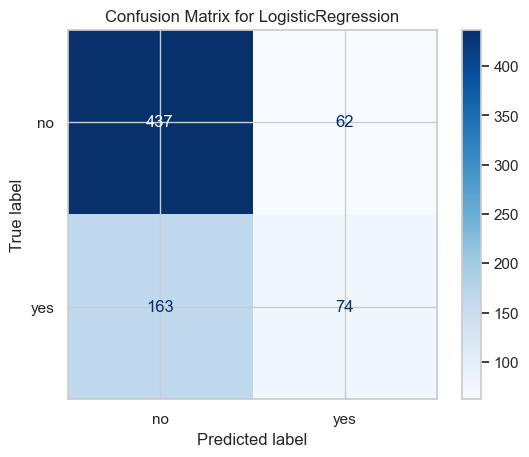

,LogisticRegression,KNeighborsClassifier,RandomForestClassifier,SVC,GradientBoostingClassifier
Accuracy,0.694293,0.550272,0.436141,0.695652,0.667120
Precision,0.669014,0.540520,0.450690,0.669557,0.645809
Recall,0.694293,0.550272,0.436141,0.695652,0.667120
F1 Score,0.666952,0.545083,0.443022,0.664773,0.651490


In [174]:
# Part 1 - Classification modeling - Baseline

# Step 1A - Call setup
target_column_discrete, classification_models, classification_model_classes, hyperparameters_classification, classification_metrics = classification_setup(config)
# Step 1B - Call preprocessor
target_column_discrete, numerical_columns, categorical_columns, X_train, X_test, y_train, y_test, preprocessor = classification_preprocessor(df, config)
# Step 1C - Perform classification modeling - Baseline
classification_baseline(df, classification_models, preprocessor, X_train, X_test, y_train, y_test)

# Run time:4s

#### Hyperparameters tuning

In [175]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# ###################################################################
# Perform the Classification modeling - with hyperparameters tuning
# ###################################################################

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
# Perform the Classification modeling - with hyperparameters tuning
# ###################################################################

def classification_models_hyperparameters(df, classification_models, hyperparameters_classification, preprocessor, X_train, X_test, y_train, y_test, config):

    """
    This function performs the following steps:
        1. Imports the required libraries
        2. Creates a dictionary of classification models
        3. Preprocesses the data for classification
        4. Creates a pipeline for each model
        5. Defines a dictionary of hyperparameters for each model
        6. Fits the GridSearchCV object to the training data
        7. Predicts the target on the testing data
        8. Calculates the metrics
        9. Prints the best model based on the F1 score
        10. Returns the metrics dataframe

    Args:
        df: The input dataframe containing the data.
        models: A list of classification models to be used.
        hyperparameters: A dictionary containing the hyperparameters for each model.

    Returns:
        metrics_tuned_df: A dataframe containing the metrics for each model.
    """
    # performance is a string that can take one of three values: 'low', 'mid', 'high'

    """
    This function performs the following steps:
        1. Imports the required libraries
        2. Creates a dictionary of classification models
        3. Preprocesses the data for classification
        4. Creates a pipeline for each model
        5. Defines a dictionary of hyperparameters for each model
        6. Fits the GridSearchCV object to the training data
        7. Predicts the target on the testing data
        8. Calculates the metrics
        9. Prints the best model based on the R2 score
        10. Returns the metrics dataframe
    """
    def print_separator():
        """
        This function performs the following steps:
            1. Print a separator line to the console.
        """
        print("-"*30)
        
    # Use the classification_models dictionary directly
    models = classification_models
    # print the dictionary of models
    print ('The classification models are:')
    print(models)
    print_separator()

    print("Part 2 - Classification Models with Hyperparameter tuning")
    print_separator()

    # print the Classification tuning optimum setting
    print(f"Classification tuning optimum is: {config['classification_tuning_performance_set_optimum']}") 
    # Print the hyperparameters dictionary
    print(hyperparameters_classification)
    print_separator()

    # Create an empty dictionary to store the metrics
    metrics_tuned = {}

    # For each model, calculate the metrics and store in the dictionary
    for name, model in models.items():
                # print the name of the model
        print("--- Model running (with hyperparameters tuning ): ", name)
        logging.info("--- 1. Creating a pipeline for the model")
        # Create a pipeline
        pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', model)])
        logging.info("--- 2. Creating a GridSearchCV object")
        # Create a GridSearchCV object
        grid_search = GridSearchCV(pipeline, hyperparameters_classification[name], cv=5, n_jobs=-1)
        logging.info("--- 3. Fitting the GridSearchCV object to the training data")
        # Fit the GridSearchCV object to the training data
        grid_search.fit(X_train, y_train)
        logging.info("--- 4. Predicting the target on the testing data")
        # Predict the target on the testing data
        logging.info("--- 5. Calculating the metrics")
        y_pred = grid_search.predict(X_test)
        # Calculate the accuracy
        accuracy = accuracy_score(y_test, y_pred)
        # Calculate the precision
        precision = precision_score(y_test, y_pred, average='weighted')
        # Calculate the recall
        recall = recall_score(y_test, y_pred, average='weighted')
        # Calculate the F1 score
        f1 = f1_score(y_test, y_pred, average='weighted')
        # Store the metrics in the dictionary
        metrics_tuned[name] = [accuracy, precision, recall, f1]

        # Create a dataframe from the metrics dictionary
        logging.info("--- Creating a dataframe from the metrics dictionary")
        metrics_tuned_df = pd.DataFrame(metrics_tuned, index=['Accuracy', 'Precision', 'Recall', 'F1 Score'])

    # Print the metrics_tuned_df dataframe
    print(metrics_tuned_df)

    print_separator()
    # Print the bext model based on the metrics
    # Print the best model based on F1 Score with 3 decimal places
    print("Best model based on F1 Score:", metrics_tuned_df.loc['F1 Score'].idxmax(), ", with a F1 Score of: ", round(metrics_tuned_df.loc['F1 Score'].max(), 3))

    # Assign the best model based on the F1 Score
    best_model = metrics_tuned_df.loc['F1 Score'].idxmax()

    # Print the best model and its name
    print(f"Best model: ", best_model)
    
    # From hyperparameters_classification, print the hyperparameters for the best_model
    print(f"Hyperparameters for the best model ({best_model}): {hyperparameters_classification[best_model]}")

    logging.info("--- Classification Baseline Models - Completed")
    
    # With the best model, print the confusion matrix
    # Get the best model
    best_model = metrics_tuned_df.loc['F1 Score'].idxmax()
    # Get the best model object
    best_model_object = models[best_model]
    # Create a pipeline with the best model
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', best_model_object)])
    # Fit the pipeline to the training data
    pipeline.fit(X_train, y_train)
    # Predict the target on the testing data
    y_pred = pipeline.predict(X_test)
    # Calculate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    # Create a confusion matrix display
    cmd = ConfusionMatrixDisplay(cm, display_labels=pipeline.classes_)
    # Plot the confusion matrix
    cmd.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {best_model}')
    plt.show()

    return metrics_tuned_df

# def classification_models_hyperparameters(df, models, hyperparameters_classification):

Classification: Optimum tuning performance set to: {'LogisticRegression': {'classifier__C': [0.1, 1.0]}, 'KNeighborsClassifier': {'classifier__n_neighbors': [3, 5]}, 'RandomForestClassifier': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [None, 10]}, 'SVC': {'classifier__C': [0.1, 1.0], 'classifier__kernel': ['linear', 'rbf']}, 'GradientBoostingClassifier': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [3, 5]}}
Verifying Numerical columns:  Index(['Campaign Calls'], dtype='object')
Verifying Categorical_columns :  Index(['Age Group', 'Credit Default', 'Education Group', 'Marital Status',
       'Occupation Group', 'On Loan', 'Previous Contact'],
      dtype='object')
The classification models are:
{'LogisticRegression': LogisticRegression(), 'KNeighborsClassifier': KNeighborsClassifier(), 'RandomForestClassifier': RandomForestClassifier(), 'SVC': SVC(), 'GradientBoostingClassifier': GradientBoostingClassifier()}
------------------------------
Par

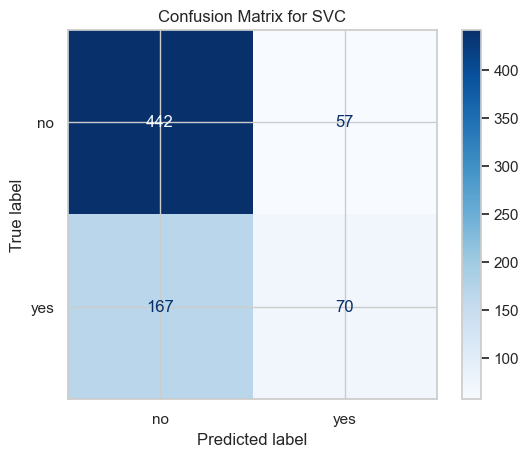

,LogisticRegression,KNeighborsClassifier,RandomForestClassifier,SVC,GradientBoostingClassifier
Accuracy,0.694293,0.550272,0.554348,0.697011,0.667120
Precision,0.669014,0.540520,0.512723,0.671733,0.645809
Recall,0.694293,0.550272,0.554348,0.697011,0.667120
F1 Score,0.666952,0.545083,0.529433,0.667512,0.651490


In [176]:
# Part 2 - Classification modeling - with hyperparameters tuning

# Step 2A - Call setup
target_column_discrete, classification_models, classification_model_classes, hyperparameters_classification, classification_metrics = classification_setup(config)

# Step 2B - Call preprocessor
target_column_discrete, numerical_columns, categorical_columns, X_train, X_test, y_train, y_test, preprocessor = classification_preprocessor(df, config)

# Step 2C - Perform classification modeling - with hyperparameters tuning
classification_models_hyperparameters(df, classification_models, hyperparameters_classification, preprocessor, X_train, X_test, y_train, y_test, config)

In [177]:
# ###################################################################
# Update the config.yaml file with the new hyperparameters
# ###################################################################

# Import the ruamel.yaml module
import ruamel.yaml

def update_config_yaml(path, key, value):
    """
    This function updates the config.yaml file with the new value for the specified key.
    """
    yaml = ruamel.yaml.YAML()
    yaml.preserve_quotes = True  # Ensures quotes remain unchanged

    # Load existing YAML file
    with open(path, "r") as file:
        config = yaml.load(file)

    # Modify a specific value (example: changing hyperparameters)
    config[key] = value

    # Save back to file without altering formatting
    with open(path, "w") as file:
        yaml.dump(config, file)
    
    return config

#### Update tuning_performance = 1, to run fast tuning

Classification: Optimum tuning performance set to: {'LogisticRegression': {'classifier__C': [0.1, 1.0]}, 'KNeighborsClassifier': {'classifier__n_neighbors': [3, 5]}, 'RandomForestClassifier': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [None, 10]}, 'SVC': {'classifier__C': [0.1, 1.0], 'classifier__kernel': ['linear', 'rbf']}, 'GradientBoostingClassifier': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [3, 5]}}
Target column: Subscription Status
------------------------------
Classification models: {'LogisticRegression': LogisticRegression(), 'KNeighborsClassifier': KNeighborsClassifier(), 'RandomForestClassifier': RandomForestClassifier(), 'SVC': SVC(), 'GradientBoostingClassifier': GradientBoostingClassifier()}
------------------------------
Classification tuning optimum is: 1
Hyperparameters classification: {'LogisticRegression': {'classifier__C': [0.1, 1.0]}, 'KNeighborsClassifier': {'classifier__n_neighbors': [3, 5]}, 'RandomForestClassifier

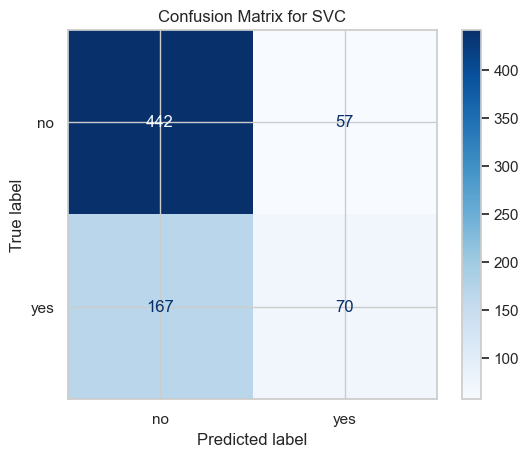

,LogisticRegression,KNeighborsClassifier,RandomForestClassifier,SVC,GradientBoostingClassifier
Accuracy,0.694293,0.550272,0.546196,0.697011,0.667120
Precision,0.669014,0.540520,0.507668,0.671733,0.645809
Recall,0.694293,0.550272,0.546196,0.697011,0.667120
F1 Score,0.666952,0.545083,0.523566,0.667512,0.651490


In [178]:
# Define the path to the config.yaml file
config_path = './src/config.yaml'

# Call the function to update the config.yaml file with the new hyperparameters
# Set the tuning performance to 1 to 3 (1=Fast, 2=Slow)
tuning_performance = 1
config = update_config_yaml(config_path, 'classification_tuning_performance_set_optimum', tuning_performance)

# Call function: classification_setup
target_column_discrete, classification_models, classification_model_classes, hyperparameters_classification, classification_metrics = classification_setup(config)

# Call function: classification_setup_results
classification_setup_results(target_column_discrete, classification_models, hyperparameters_classification, classification_metrics, config)

# Perform classification modeling with hyperparameters tuning
classification_models_hyperparameters(df, classification_models, hyperparameters_classification, preprocessor, X_train, X_test, y_train, y_test, config)

#### Update tuning_performance = 2, to run slow tuning

Classification: Optimum tuning performance set to: {'LogisticRegression': {'classifier__C': [0.01, 0.1, 1.0, 10.0]}, 'KNeighborsClassifier': {'classifier__n_neighbors': [3, 5, 7]}, 'RandomForestClassifier': {'classifier__n_estimators': [100, 200, 300], 'classifier__max_depth': [None, 10, 20]}, 'SVC': {'classifier__C': [0.1, 1.0, 10.0], 'classifier__kernel': ['linear', 'rbf', 'poly']}, 'GradientBoostingClassifier': {'classifier__n_estimators': [100, 200, 300], 'classifier__max_depth': [3, 5, 10]}}
Target column: Subscription Status
------------------------------
Classification models: {'LogisticRegression': LogisticRegression(), 'KNeighborsClassifier': KNeighborsClassifier(), 'RandomForestClassifier': RandomForestClassifier(), 'SVC': SVC(), 'GradientBoostingClassifier': GradientBoostingClassifier()}
------------------------------
Classification tuning optimum is: 2
Hyperparameters classification: {'LogisticRegression': {'classifier__C': [0.01, 0.1, 1.0, 10.0]}, 'KNeighborsClassifier': {

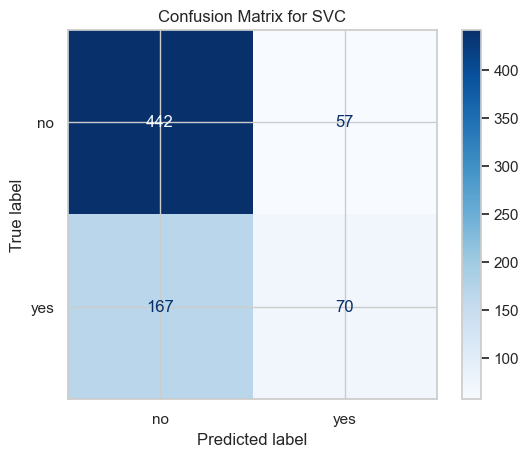

,LogisticRegression,KNeighborsClassifier,RandomForestClassifier,SVC,GradientBoostingClassifier
Accuracy,0.698370,0.582880,0.563859,0.697011,0.667120
Precision,0.671807,0.564058,0.528357,0.671733,0.645809
Recall,0.698370,0.582880,0.563859,0.697011,0.667120
F1 Score,0.654748,0.572026,0.542537,0.667512,0.651490


In [179]:
# Define the path to the config.yaml file
config_path = './src/config.yaml'

# Call the function to update the config.yaml file with the new hyperparameters
# Set the tuning performance to 1 to 3 (1=Fast, 2=Slow)
tuning_performance = 2
config = update_config_yaml(config_path, 'classification_tuning_performance_set_optimum', tuning_performance)

# Call function: classification_setup
target_column_discrete, classification_models, classification_model_classes, hyperparameters_classification, classification_metrics = classification_setup(config)

# Call function: classification_setup_results
classification_setup_results(target_column_discrete, classification_models, hyperparameters_classification, classification_metrics, config)

# Perform classification modeling with hyperparameters tuning
classification_models_hyperparameters(df, classification_models, hyperparameters_classification, preprocessor, X_train, X_test, y_train, y_test, config)

#### Findings:

At this junction, the best results:

1. Baseline:
Best model based on F1 Score: LogisticRegression , with a F1 Score of:  0.667

2. With hyperparameter tuning:
Best model based on F1 Score: SVC , with a F1 Score of:  0.668

#### Proceed at this point to fine tune ine the dataset and use Logistic Regression to determine the best feature selection before attmepting the hyperparameter testing with the best model.

In [181]:
# Load back the dataset
df = pd.read_csv('./data/eda_completed.csv')

#### Set the classification_models to list only Logistic Regression in order to run through the following combinations:
Check for improvement in the F1 Score when:
1. Dropping column one-by-one
2. Dropping column two-by-two
3. Dropping column three-by-three

The classification models are:
{'LogisticRegression': LogisticRegression()}
------------------------------
Part 1 - Baseline of Classification Models
------------------------------
--- Model running:  LogisticRegression
           LogisticRegression
Accuracy             0.694293
Precision            0.669014
Recall               0.694293
F1 Score             0.666952
------------------------------
           LogisticRegression
Accuracy             0.694293
Precision            0.669014
Recall               0.694293
F1 Score             0.666952
------------------------------
Best model based on F1 Score: LogisticRegression , with a F1 Score of:  0.667
Hyperparameters of the best model:
LogisticRegression()


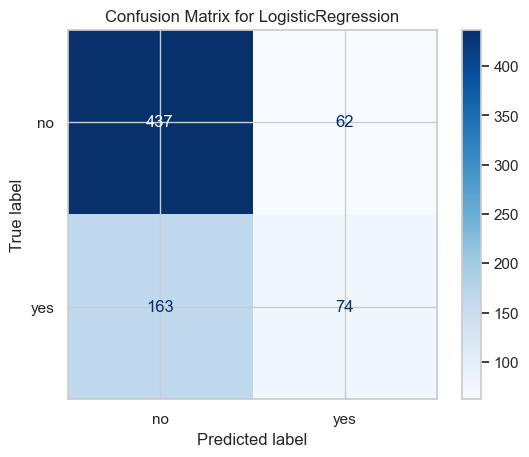

,LogisticRegression
Accuracy,0.694293
Precision,0.669014
Recall,0.694293
F1 Score,0.666952


In [182]:
# Set only the Logistic Regression model for baseline for quick assessment
classification_models = {'LogisticRegression': LogisticRegression()}

# Perform classification modeling - Logistic Regression only
classification_baseline(df, classification_models, preprocessor, X_train, X_test, y_train, y_test)

In [183]:
# Display df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3676 entries, 0 to 3675
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Marital Status       3676 non-null   object
 1   Credit Default       3676 non-null   object
 2   Campaign Calls       3676 non-null   int64 
 3   Subscription Status  3676 non-null   object
 4   Previous Contact     3676 non-null   object
 5   Age Group            3676 non-null   object
 6   On Loan              3676 non-null   object
 7   Education Group      3676 non-null   object
 8   Occupation Group     3676 non-null   object
dtypes: int64(1), object(8)
memory usage: 258.6+ KB


#### Dropping column one-by-one

In [184]:
# Excluding the target column, place feature_columns in a list
feature_columns = df.columns.tolist()
feature_columns.remove(target_column_discrete)
# Print the feature columns
print('Feature columns:', feature_columns)
# Print the target column
print('Target column:', target_column_discrete)

Feature columns: ['Marital Status', 'Credit Default', 'Campaign Calls', 'Previous Contact', 'Age Group', 'On Loan', 'Education Group', 'Occupation Group']
Target column: Subscription Status


In [185]:
# Set only the Logistic Regression model for baseline for quick assessment
classification_models = {'LogisticRegression': LogisticRegression()}

# Perform classification modeling - Logistic Regression only
metrics_df = classification_baseline_LogisticRegression(df, classification_models)

# Save the F1 score to a variable, F1_Score to 3 decimal places
F1_Score = round(metrics_df.loc['F1 Score'].max(), 3)
print("Updated F1_Score:", F1_Score)

Quick run of Logistic Regression
------------------------------
Best model based on F1 Score: LogisticRegression , with a F1 Score of:  0.667
Updated F1_Score: 0.667


#### Dropping column one-by-one

In [186]:
# For each feature_columns, perform classification_models = {'LogisticRegression': LogisticRegression()} by dropping
# the feature_columns one at a time and calculate the F1_Score

# Create a list to store the F1_Score for each feature_columns
F1_Score_list = []
# Create a list to store the feature_columns
feature_columns_list = []
# Loop through each feature_columns
for feature in feature_columns:
    print_separator()
    # Print the feature that is being dropped
    print("Dropping feature:", feature)
    # Print remaining feature_columns
    print("Remaining feature columns:", [f for f in feature_columns if f != feature])

    # Create a new dataframe by dropping the feature_columns
    df_new = df.drop(feature, axis=1)
    # Perform classification modeling - Logistic Regression only
    metrics_df = classification_baseline_LogisticRegression(df_new, classification_models)

    # Save the F1 score to a variable, F1_Score to 3 decimal places
    F1_Score = round(metrics_df.loc['F1 Score'].max(), 3)

    # Append the F1_Score to the F1_Score_list
    F1_Score_list.append(F1_Score)
    # Append the feature that was dropped to the feature_columns_list
    feature_columns_list.append(feature)

# Print F1_Score_list as a table with feature that was dropped, F1_Score
# Create a dataframe from the F1_Score_list and feature_columns_list
F1_Score_df = pd.DataFrame({'Feature_Dropped': feature_columns_list, 'F1_Score': F1_Score_list})
# Print the F1_Score_df dataframe
print(F1_Score_df)

..............................
Dropping feature: Marital Status
Remaining feature columns: ['Credit Default', 'Campaign Calls', 'Previous Contact', 'Age Group', 'On Loan', 'Education Group', 'Occupation Group']
Quick run of Logistic Regression
------------------------------
Best model based on F1 Score: LogisticRegression , with a F1 Score of:  0.667
..............................
Dropping feature: Credit Default
Remaining feature columns: ['Marital Status', 'Campaign Calls', 'Previous Contact', 'Age Group', 'On Loan', 'Education Group', 'Occupation Group']
Quick run of Logistic Regression
------------------------------
Best model based on F1 Score: LogisticRegression , with a F1 Score of:  0.667
..............................
Dropping feature: Campaign Calls
Remaining feature columns: ['Marital Status', 'Credit Default', 'Previous Contact', 'Age Group', 'On Loan', 'Education Group', 'Occupation Group']
Quick run of Logistic Regression
------------------------------
Best model based on

#### Dropping column two-by-two

In [187]:
# For each pair of feature_columns, perform classification_models = {'LogisticRegression': LogisticRegression()} by dropping
# the feature_columns two at a time and calculate the F1_Score
from itertools import combinations

# Create a list to store the F1_Score for each pair of feature_columns
F1_Score_list = []
# Create a list to store the pairs of feature_columns
feature_columns_list = []

# Loop through all combinations of two features
for feature_pair in combinations(feature_columns, 2):
    print_separator()
    # Print the features that are being dropped
    print("Dropping features:", feature_pair)
    # Print remaining feature_columns
    print("Remaining feature columns:", [f for f in feature_columns if f not in feature_pair])
    
    # Create a new dataframe by dropping the feature_columns
    df_new = df.drop(list(feature_pair), axis=1)
    # Perform classification modeling - Logistic Regression only
    metrics_df = classification_baseline_LogisticRegression(df_new, classification_models)

    # Save the F1 score to a variable, F1_Score to 3 decimal places
    F1_Score = round(metrics_df.loc['F1 Score'].max(), 3)

    # Append the F1_Score to the F1_Score_list
    F1_Score_list.append(F1_Score)
    # Append the pair of features that were dropped to the feature_columns_list
    feature_columns_list.append(feature_pair)

# Print F1_Score_list as a table with feature that was dropped, F1_Score
# Create a dataframe from the F1_Score_list and feature_columns_list and rnumber of remaining feature_columns
F1_Score_df = pd.DataFrame({'Feature_Dropped': feature_columns_list, 'F1_Score': F1_Score_list})
# Print the F1_Score_df dataframe
print(F1_Score_df)


..............................
Dropping features: ('Marital Status', 'Credit Default')
Remaining feature columns: ['Campaign Calls', 'Previous Contact', 'Age Group', 'On Loan', 'Education Group', 'Occupation Group']
Quick run of Logistic Regression
------------------------------
Best model based on F1 Score: LogisticRegression , with a F1 Score of:  0.667
..............................
Dropping features: ('Marital Status', 'Campaign Calls')
Remaining feature columns: ['Credit Default', 'Previous Contact', 'Age Group', 'On Loan', 'Education Group', 'Occupation Group']
Quick run of Logistic Regression
------------------------------
Best model based on F1 Score: LogisticRegression , with a F1 Score of:  0.667
..............................
Dropping features: ('Marital Status', 'Previous Contact')
Remaining feature columns: ['Credit Default', 'Campaign Calls', 'Age Group', 'On Loan', 'Education Group', 'Occupation Group']
Quick run of Logistic Regression
------------------------------
Best

In [188]:
# Reload config.yaml file
with open(config_path, 'r', encoding='utf-8') as file: # open the config.yaml file
    config = yaml.safe_load(file) # load the configuration


In [189]:
# Display the initial dataframe
print("Initial DataFrame:")
print_separator()
df_initial.info()

Initial DataFrame:
..............................
<class 'pandas.core.frame.DataFrame'>
Index: 35948 entries, 0 to 41186
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    35948 non-null  object
 1   Occupation             35948 non-null  object
 2   Marital Status         35948 non-null  object
 3   Education Level        35948 non-null  object
 4   Credit Default         35948 non-null  object
 5   Housing Loan           15230 non-null  object
 6   Personal Loan          31935 non-null  object
 7   Contact Method         35948 non-null  object
 8   Campaign Calls         35948 non-null  int64 
 9   Previous Contact Days  35948 non-null  int64 
 10  Subscription Status    35948 non-null  object
dtypes: int64(2), object(9)
memory usage: 3.3+ MB


In [190]:
# Display df
print("DataFrame after EDA:")
print_separator()
df.info()

DataFrame after EDA:
..............................
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3676 entries, 0 to 3675
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Marital Status       3676 non-null   object
 1   Credit Default       3676 non-null   object
 2   Campaign Calls       3676 non-null   int64 
 3   Subscription Status  3676 non-null   object
 4   Previous Contact     3676 non-null   object
 5   Age Group            3676 non-null   object
 6   On Loan              3676 non-null   object
 7   Education Group      3676 non-null   object
 8   Occupation Group     3676 non-null   object
dtypes: int64(1), object(8)
memory usage: 258.6+ KB


Classification: Optimum tuning performance set to: {'LogisticRegression': {'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}, 'KNeighborsClassifier': {'classifier__n_neighbors': [1, 3, 5, 7, 9, 11]}, 'RandomForestClassifier': {'classifier__n_estimators': [50, 100, 200, 300, 500], 'classifier__max_depth': [None, 10]}, 'SVC': {'classifier__C': [0.1, 1.0], 'classifier__kernel': ['linear', 'rbf', 'poly', 'sigmoid']}, 'GradientBoostingClassifier': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [3, 5, 10, 15]}}
Target column: Subscription Status
------------------------------
Classification models: {'LogisticRegression': LogisticRegression(), 'KNeighborsClassifier': KNeighborsClassifier(), 'RandomForestClassifier': RandomForestClassifier(), 'SVC': SVC(), 'GradientBoostingClassifier': GradientBoostingClassifier()}
------------------------------
Classification tuning optimum is: 3
Hyperparameters classification: {'LogisticRegression': {'classifier__C': [0.001, 0.01, 0.1

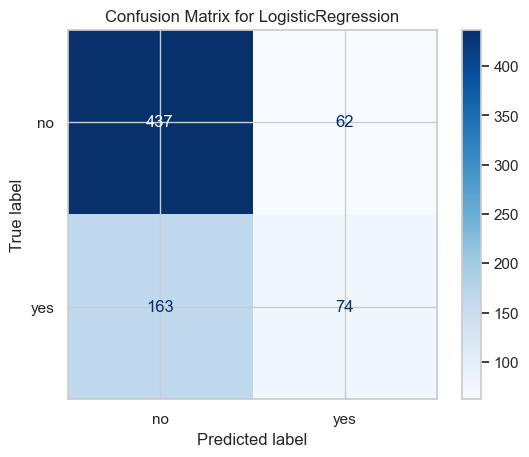

The classification models are:
{'LogisticRegression': LogisticRegression(), 'KNeighborsClassifier': KNeighborsClassifier(), 'RandomForestClassifier': RandomForestClassifier(), 'SVC': SVC(), 'GradientBoostingClassifier': GradientBoostingClassifier()}
------------------------------
Part 2 - Classification Models with Hyperparameter tuning
------------------------------
Classification tuning optimum is: 3
{'LogisticRegression': {'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}, 'KNeighborsClassifier': {'classifier__n_neighbors': [1, 3, 5, 7, 9, 11]}, 'RandomForestClassifier': {'classifier__n_estimators': [50, 100, 200, 300, 500], 'classifier__max_depth': [None, 10]}, 'SVC': {'classifier__C': [0.1, 1.0], 'classifier__kernel': ['linear', 'rbf', 'poly', 'sigmoid']}, 'GradientBoostingClassifier': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [3, 5, 10, 15]}}
------------------------------
--- Model running (with hyperparameters tuning ):  LogisticRegression
--- Model

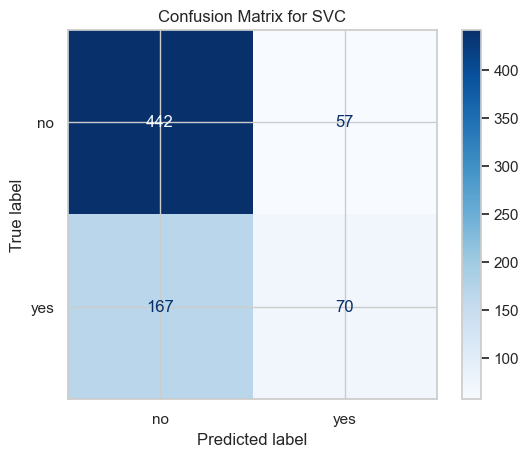

,LogisticRegression,KNeighborsClassifier,RandomForestClassifier,SVC,GradientBoostingClassifier
Accuracy,0.698370,0.620924,0.551630,0.697011,0.667120
Precision,0.671807,0.585237,0.516558,0.671733,0.645809
Recall,0.698370,0.620924,0.551630,0.697011,0.667120
F1 Score,0.654748,0.596087,0.531007,0.667512,0.651490


In [191]:
##### Classification_setup ##### xxx
# Step 1 - Call Classification_setup
target_column_discrete, classification_models, classification_model_classes, hyperparameters_classification, classification_metrics = classification_setup(config)
# Display Classification_setup_results
classification_setup_results(target_column_discrete, classification_models, hyperparameters_classification, classification_metrics, config)

##### Classification_preprocessor #####
# Step 2- Call Classification_preprocessor
target_column_discrete, numerical_columns, categorical_columns, X_train, X_test, y_train, y_test, preprocessor = classification_preprocessor(df, config)
# Call Classification_preprocessor_result
classification_preprocessor_results(target_column_discrete, df, numerical_columns, categorical_columns, X_train, X_test, y_train, y_test, preprocessor)


##### Part 1 - Classification modeling - Baseline #####
# Step 3 - Perform classification modeling - Baseline
classification_baseline(df, classification_models, preprocessor, X_train, X_test, y_train, y_test)

##### Part 2 - Classification modeling -  with hyperparameters #####
# Step 4 - Perform classification modeling - with hyperparameters tuning
classification_models_hyperparameters(df, classification_models, hyperparameters_classification, preprocessor, X_train, X_test, y_train, y_test, config)


#### The EDA with the modeling performance completed

The following are observed.

1. Feature `Age` is a range of numnber that has little performance impac to positive subscription and this feature is best encoded by binning into age range or `Age Group`
2. Similar for categorical features of `Occupation`, `Education Level`, which are encoded to group them into similar characteristics, to new features `Occupation Group` and `Education Group`
3. For `Marital Status`, the value 'divorced' is renamed as 'single'
4. For `Credit Default`, the value 'yes' is dropped while the 'unknown' is renamed as 'undisclosed'.
5. Both `Housing Loan` and `Personal Loan`  have large count of missing values. The transformation of these 2 features into a new `On loan` features reduces the missing values by taking into account the 'yes' in either both features, for example.
6. `Contact Method` is dropped as the values of 'Cell' 'telephone' 'cellular' and 'Telephone' mean the same communication method. A call is a call.
7. `Campaign Calls`, after removal of negative numbers, has its outliers removed using 1.5xIQR. The config.ymal hosts this configuration numnber that can assist future performance check by fine tuning this number easily using config.yaml.
8. `Previous Contact Days` has high count of '999' which refer to 'no prior contact'. This feature is thus transformed into a new feature `Previous Contact`
9. Lastly the target `Subscription Status` has imbalance distribution. The **best F1 Score is about 0.67**.
10. The tuning of hyperparameters did not improve the best model.
11. The dataset has many duplicates due to the categorial characteristics of the many features.


Some improvements
- Handle class imbalance (e.g., using SMOTE).
- Other ways of feature engineering may boost performance.

Summary:
- Decent but not perfect.
- A score of 0.67 suggests that the model is doing a reasonable job but has room for improvement.
- It is better than random guessing, indicating it is a moderately effective model.

#### Hence, AI-Vive-Banking is able to effectively identify, using the features of the dataset and the establised machine learning pipeline, to categorise the `Subscription Status` of the clients, thus enhancing the resource allocation and better customer engagement.

Thank you.